# 전체 구조

```
예측 결과 형태:
  최저가 (q10) ─────── 중간가 (q50) ─────── 최고가 (q90)
     1,200만원              1,500만원              1,850만원

평가 지표:
  - Pinball Loss   : 각 분위수 예측 정확도
  - Coverage Rate  : 실제값이 [q10~q90] 범위 안에 드는 비율
  - Interval Width : 예측 범위 평균 폭 (좁을수록 정밀)
  - MAE (q50)      : 중간값 예측 오차
```

✅ 전처리 완료 | Train: (9293, 32) / Test: (2324, 32)
예측 분위수: [0.1, 0.5, 0.9]
  q=0.1 완료
  q=0.5 완료
  q=0.9 완료

  [Linear Quantile]
  Coverage Rate   : 81.0%  (목표: ~80%)
  Interval Width  : 913 만원  (좁을수록 정밀)
  MAE (q50)       : 381.5 만원
  Pinball q10     : 81.4
  Pinball q50     : 190.7
  Pinball q90     : 152.8
  q=0.1 완료
  q=0.5 완료
  q=0.9 완료

  [LightGBM Quantile]
  Coverage Rate   : 74.1%  (목표: ~80%)
  Interval Width  : 642 만원  (좁을수록 정밀)
  MAE (q50)       : 283.7 만원
  Pinball q10     : 61.1
  Pinball q50     : 141.9
  Pinball q90     : 133.4
  q=0.1 완료
  q=0.5 완료
  q=0.9 완료

  [XGBoost Quantile]
  Coverage Rate   : 72.4%  (목표: ~80%)
  Interval Width  : 651 만원  (좁을수록 정밀)
  MAE (q50)       : 287.8 만원
  Pinball q10     : 64.9
  Pinball q50     : 143.9
  Pinball q90     : 137.5
                   Coverage(%)  Width(만원)  MAE_q50  Pinball_q10  Pinball_q50  \
model                                                                          
Linear Quantile           81.0      913.0    381.5       

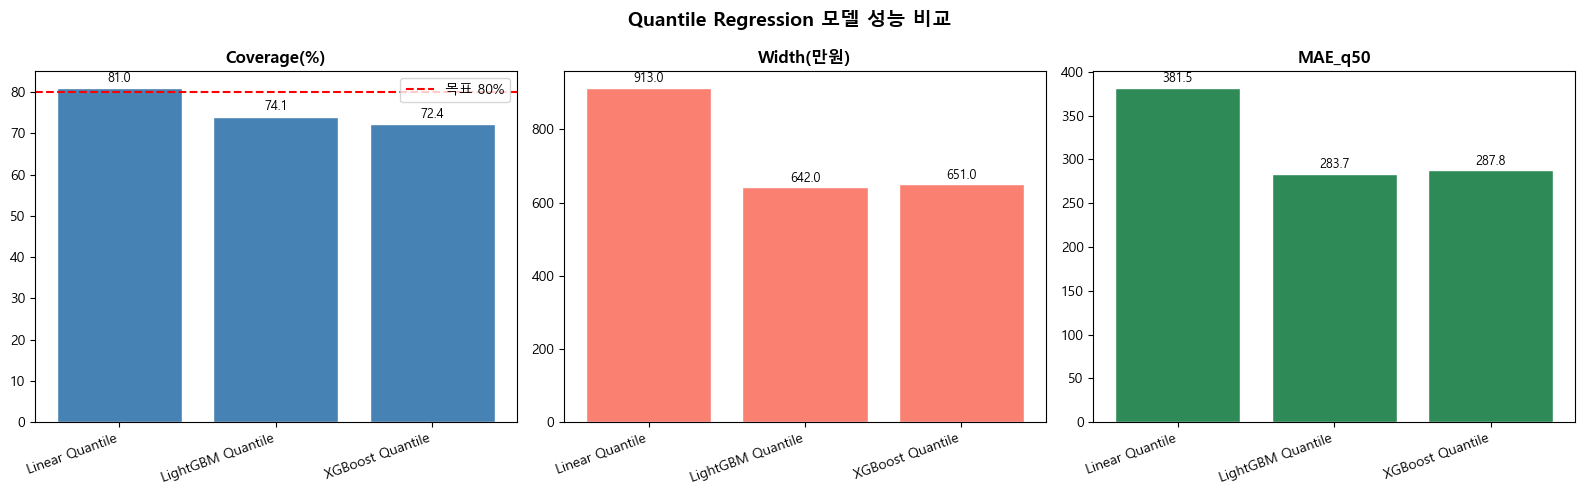

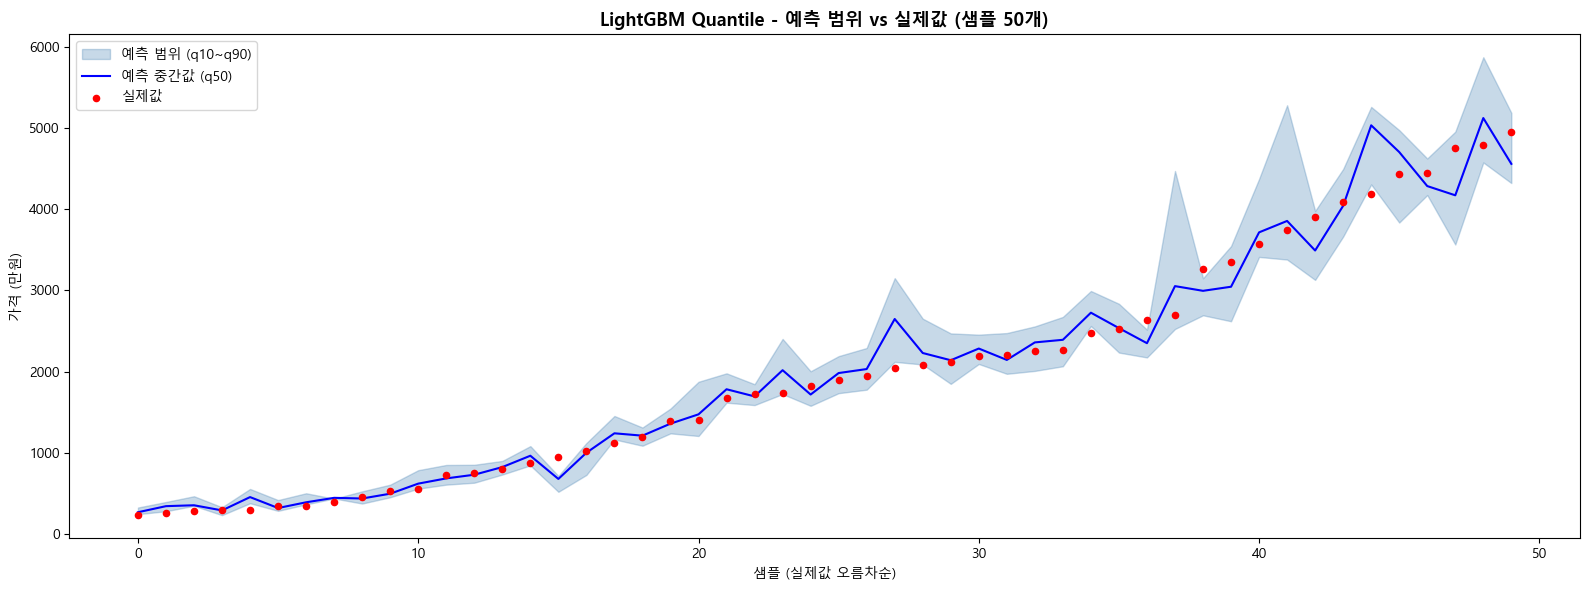

              범위폭  범위폭(%)
가격대                      
~1000       269.5   353.7
1000~2000   457.9    31.1
2000~3000   706.2    28.3
3000~5000  1116.4    29.2
5000~      1890.2    27.8


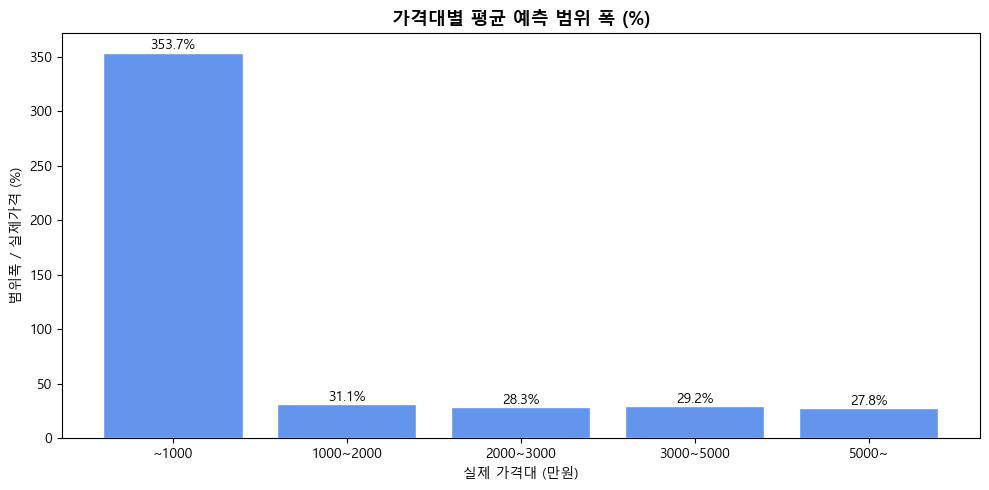

In [1]:
### 전처리 (동일 유지)


# ============================================================
# Quantile Regression 기반 중고차 가격 범위 예측
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import QuantileRegressor

# 데이터 로드
DATA_PATH = r"C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\encar_feature_processed_with_model_avg_te.csv"
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 피처 / 타겟
DROP_COLS = ['매물ID', '모델']
TARGET    = '현재가격_만원'

binary_cols = [c for c in df.columns
               if df[c].nunique() == 2 and set(df[c].dropna().unique()) <= {0,1}]
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.03)
vt.fit(df[binary_cols])
removed = [c for c, s in zip(binary_cols, vt.get_support()) if not s]

X = df.drop(columns=DROP_COLS + [TARGET] + removed)
y = df[TARGET]

# 로그 변환
y_log = np.log1p(y)

# Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 선형 모델용 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

QUANTILES = [0.1, 0.5, 0.9]   # 하한 / 중간 / 상한
print(f"✅ 전처리 완료 | Train: {X_train.shape} / Test: {X_test.shape}")
print(f"예측 분위수: {QUANTILES}")


### 평가 함수 정의


def pinball_loss(y_true, y_pred, q):
    """Pinball Loss (분위수 손실)"""
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, q * err, (q - 1) * err))

def evaluate_quantile(model_name, y_true_log, preds_log: dict):
    """
    preds_log : {0.1: array, 0.5: array, 0.9: array}
    """
    # 역변환
    y_true  = np.expm1(y_true_log)
    pred_10 = np.expm1(preds_log[0.1])
    pred_50 = np.expm1(preds_log[0.5])
    pred_90 = np.expm1(preds_log[0.9])

    # 지표 계산
    coverage = np.mean((y_true >= pred_10) & (y_true <= pred_90)) * 100
    width    = np.mean(pred_90 - pred_10)
    mae_50   = mean_absolute_error(y_true, pred_50)
    pb_10    = pinball_loss(np.expm1(y_true_log), pred_10, 0.1)
    pb_50    = pinball_loss(np.expm1(y_true_log), pred_50, 0.5)
    pb_90    = pinball_loss(np.expm1(y_true_log), pred_90, 0.9)

    print(f"\n{'='*50}")
    print(f"  [{model_name}]")
    print(f"{'='*50}")
    print(f"  Coverage Rate   : {coverage:.1f}%  (목표: ~80%)")
    print(f"  Interval Width  : {width:,.0f} 만원  (좁을수록 정밀)")
    print(f"  MAE (q50)       : {mae_50:,.1f} 만원")
    print(f"  Pinball q10     : {pb_10:,.1f}")
    print(f"  Pinball q50     : {pb_50:,.1f}")
    print(f"  Pinball q90     : {pb_90:,.1f}")

    return {
        'model': model_name,
        'Coverage(%)': round(coverage, 1),
        'Width(만원)': round(width, 0),
        'MAE_q50': round(mae_50, 1),
        'Pinball_q10': round(pb_10, 1),
        'Pinball_q50': round(pb_50, 1),
        'Pinball_q90': round(pb_90, 1)
    }

results_q = []


### Model 1. Linear Quantile Regression

preds_linear = {}

for q in QUANTILES:
    model = QuantileRegressor(quantile=q, alpha=0.01, solver='highs')
    model.fit(X_train_scaled, y_train)
    preds_linear[q] = model.predict(X_test_scaled)
    print(f"  q={q} 완료")

result = evaluate_quantile("Linear Quantile", y_test, preds_linear)
results_q.append(result)

### Model 2. LightGBM Quantile

preds_lgb = {}

for q in QUANTILES:
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    preds_lgb[q] = model.predict(X_test)
    print(f"  q={q} 완료")

result = evaluate_quantile("LightGBM Quantile", y_test, preds_lgb)
results_q.append(result)

### Model 3. XGBoost Quantile

preds_xgb = {}

for q in QUANTILES:
    model = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X_train, y_train)
    preds_xgb[q] = model.predict(X_test)
    print(f"  q={q} 완료")

result = evaluate_quantile("XGBoost Quantile", y_test, preds_xgb)
results_q.append(result)


### 성능 비교표

result_df = pd.DataFrame(results_q).set_index('model')
print(result_df)


### 시각화 1. 모델별 성능 비교

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Coverage(%)', 'Width(만원)', 'MAE_q50']
colors  = ['steelblue', 'salmon', 'seagreen']
ref     = [80, None, None]   # Coverage 목표선

for ax, metric, color, target_line in zip(axes, metrics, colors, ref):
    bars = ax.bar(result_df.index, result_df[metric], color=color, edgecolor='white')
    if target_line:
        ax.axhline(target_line, color='red', linestyle='--', label=f'목표 {target_line}%')
        ax.legend()
    ax.set_title(metric, fontsize=12, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    for bar, val in zip(bars, result_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Quantile Regression 모델 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 시각화 2. 예측 범위 샘플 플롯 (LightGBM 기준)

# 테스트셋 샘플 50개로 예측 범위 시각화
n_sample = 50
idx = np.random.choice(len(y_test), n_sample, replace=False)
idx_sorted = idx[np.argsort(np.expm1(y_test.values[idx]))]

y_true_s  = np.expm1(y_test.values[idx_sorted])
pred_10_s = np.expm1(preds_lgb[0.1][idx_sorted])
pred_50_s = np.expm1(preds_lgb[0.5][idx_sorted])
pred_90_s = np.expm1(preds_lgb[0.9][idx_sorted])

fig, ax = plt.subplots(figsize=(16, 6))

x_pos = np.arange(n_sample)
ax.fill_between(x_pos, pred_10_s, pred_90_s,
                alpha=0.3, color='steelblue', label='예측 범위 (q10~q90)')
ax.plot(x_pos, pred_50_s, 'b-', linewidth=1.5, label='예측 중간값 (q50)')
ax.scatter(x_pos, y_true_s, color='red', s=20, zorder=5, label='실제값')

ax.set_title('LightGBM Quantile - 예측 범위 vs 실제값 (샘플 50개)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('샘플 (실제값 오름차순)')
ax.set_ylabel('가격 (만원)')
ax.legend()
plt.tight_layout()
plt.show()


### 시각화 3. 가격대별 예측 범위 폭 분석

y_true_all  = np.expm1(y_test.values)
pred_10_all = np.expm1(preds_lgb[0.1])
pred_50_all = np.expm1(preds_lgb[0.5])
pred_90_all = np.expm1(preds_lgb[0.9])
width_all   = pred_90_all - pred_10_all

# 가격 구간 분류
bins   = [0, 1000, 2000, 3000, 5000, 15000]
labels = ['~1000', '1000~2000', '2000~3000', '3000~5000', '5000~']
price_band = pd.cut(y_true_all, bins=bins, labels=labels)

width_by_band = pd.DataFrame({
    '가격대': price_band,
    '범위폭': width_all,
    '범위폭(%)': width_all / y_true_all * 100
}).groupby('가격대', observed=True)[['범위폭', '범위폭(%)']].mean().round(1)

print(width_by_band)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(width_by_band.index, width_by_band['범위폭(%)'],
       color='cornflowerblue', edgecolor='white')
ax.set_title('가격대별 평균 예측 범위 폭 (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('실제 가격대 (만원)')
ax.set_ylabel('범위폭 / 실제가격 (%)')
for i, v in enumerate(width_by_band['범위폭(%)']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**실행 흐름 요약**


전처리 → Linear Quantile → LightGBM Quantile → XGBoost Quantile
                                    ↓
              Coverage Rate / Interval Width / MAE(q50) 비교
                                    ↓
              최적 모델로 가격 범위 [최저 ~ 최고] 제시


## Quantile Regression 결과 해석

### 성능 비교 한눈에 보기

| 모델 | Coverage | Width | MAE(q50) | 종합 판단 |
|---|:---:|---:|---:|:---:|
| Linear Quantile | ✅ 81.0% | ❌ 913만원 | ❌ 381.5만원 | 범위만 넓혀서 커버 |
| **LightGBM Quantile** | ⚠️ 74.1% | ✅ 642만원 | ✅ 283.7만원 | **정밀하지만 Coverage 부족** |
| XGBoost Quantile | ⚠️ 72.4% | ✅ 651만원 | ✅ 287.8만원 | LightGBM과 유사 |

---

### 핵심 해석

#### ✅ Linear Quantile — "넓게 쳐서 맞춘" 모델
- Coverage 81% → 목표 달성처럼 보이지만
- Width 913만원 → **범위를 너무 넓게 잡아서 맞춘 것**
- MAE 381만원 → 중간값 예측도 부정확
- 결론: **실용성 낮음** — "1,000만원 ~ 1,900만원" 같은 무의미한 범위

#### ⚠️ LightGBM / XGBoost — "정밀하지만 Coverage 부족"
- Width 642~651만원 → Linear 대비 **270만원 더 좁고 정밀**
- MAE 284~288만원 → 중간값 예측도 훨씬 정확
- Coverage 72~74% → **실제값이 범위를 벗어나는 경우가 26~28%**
- 결론: **방향은 맞지만 분위수 범위 조정 필요**

---

### 트레이드오프 구조

```
                    Coverage ↑        Width ↓
                   (안전하게)        (정밀하게)
Linear Quantile      81%  ◀────────────▶  913만원
LightGBM/XGBoost     74%  ◀────────────▶  642만원

목표: Coverage 80% 유지하면서 Width를 최대한 좁히기
```

---

### 원인 및 해결 방향

**Coverage 부족 원인**
- q10~q90 구간이 실제 데이터 분포보다 **안쪽으로 너무 좁게 학습**
- 고가 차량(제네시스, 수입차)처럼 **가격 변동성이 큰 구간**에서 주로 이탈

**해결 방법 2가지**

```
방법 1. 분위수 범위 확장        q10/q90 → q05/q95
        예상 효과: Coverage ↑80% 이상, Width 소폭 증가

방법 2. Conformal Prediction   보정(calibration) 적용
        예상 효과: Coverage 정확히 80% 보장, Width 최소화
```

---

### 다음 단계 제언

```
1순위  LightGBM q05 / q50 / q95 로 분위수 확장
       → Coverage 목표 달성하면서 Width 최소화

2순위  가격대별 Width 분석
       → 고가 구간일수록 Width가 넓어지는지 확인

3순위  최종 모델 결정 후
       → "예상 판매가: 1,200만원 ~ 1,650만원" 형태 출력 구현
```

---

  q=0.05 완료
  q=0.5 완료
  q=0.95 완료

  [LightGBM q05/q95]  (0.05 / 0.5 / 0.95)
  Coverage Rate   : 83.3%  (목표: ~80%)
  Interval Width  : 1,050 만원
  MAE (q0.5)      : 283.7 만원
  Pinball q0.05   : 41.5
  Pinball q0.5    : 141.9
  Pinball q0.95  : 120.0
  q=0.05 완료
  q=0.5 완료
  q=0.95 완료

  [XGBoost q05/q95]  (0.05 / 0.5 / 0.95)
  Coverage Rate   : 83.9%  (목표: ~80%)
  Interval Width  : 1,072 만원
  MAE (q0.5)      : 287.8 만원
  Pinball q0.05   : 44.2
  Pinball q0.5    : 143.9
  Pinball q0.95  : 123.4
                   Coverage(%)  Width(만원)  MAE_q50
model                                             
Linear Quantile           81.0      913.0    381.5
LightGBM Quantile         74.1      642.0    283.7
XGBoost Quantile          72.4      651.0    287.8
LightGBM q05/q95          83.3     1050.0    283.7
XGBoost q05/q95           83.9     1072.0    287.8


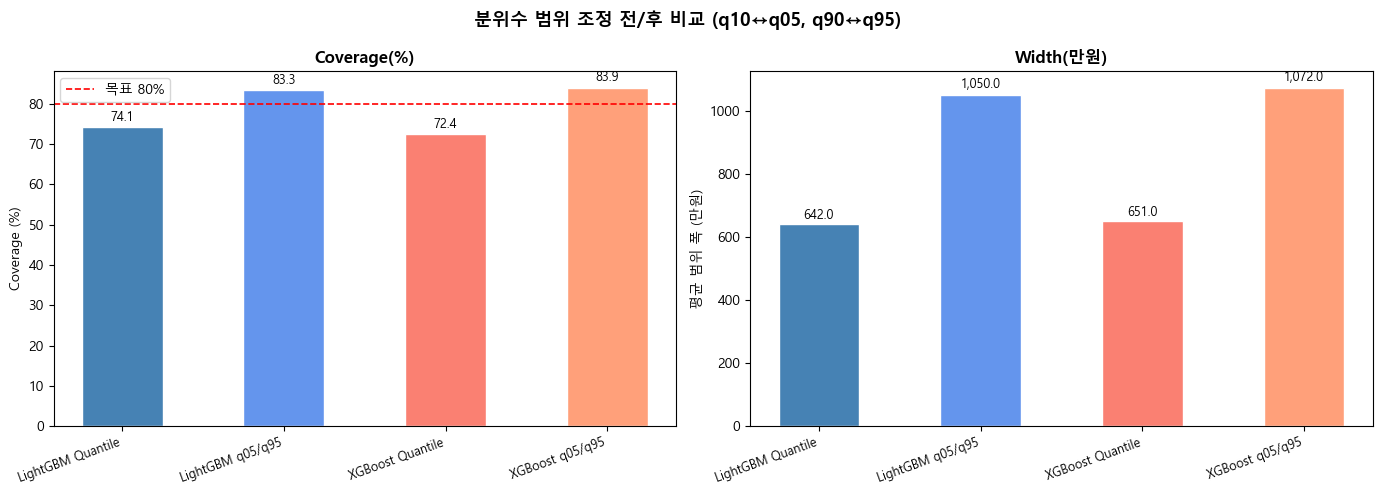

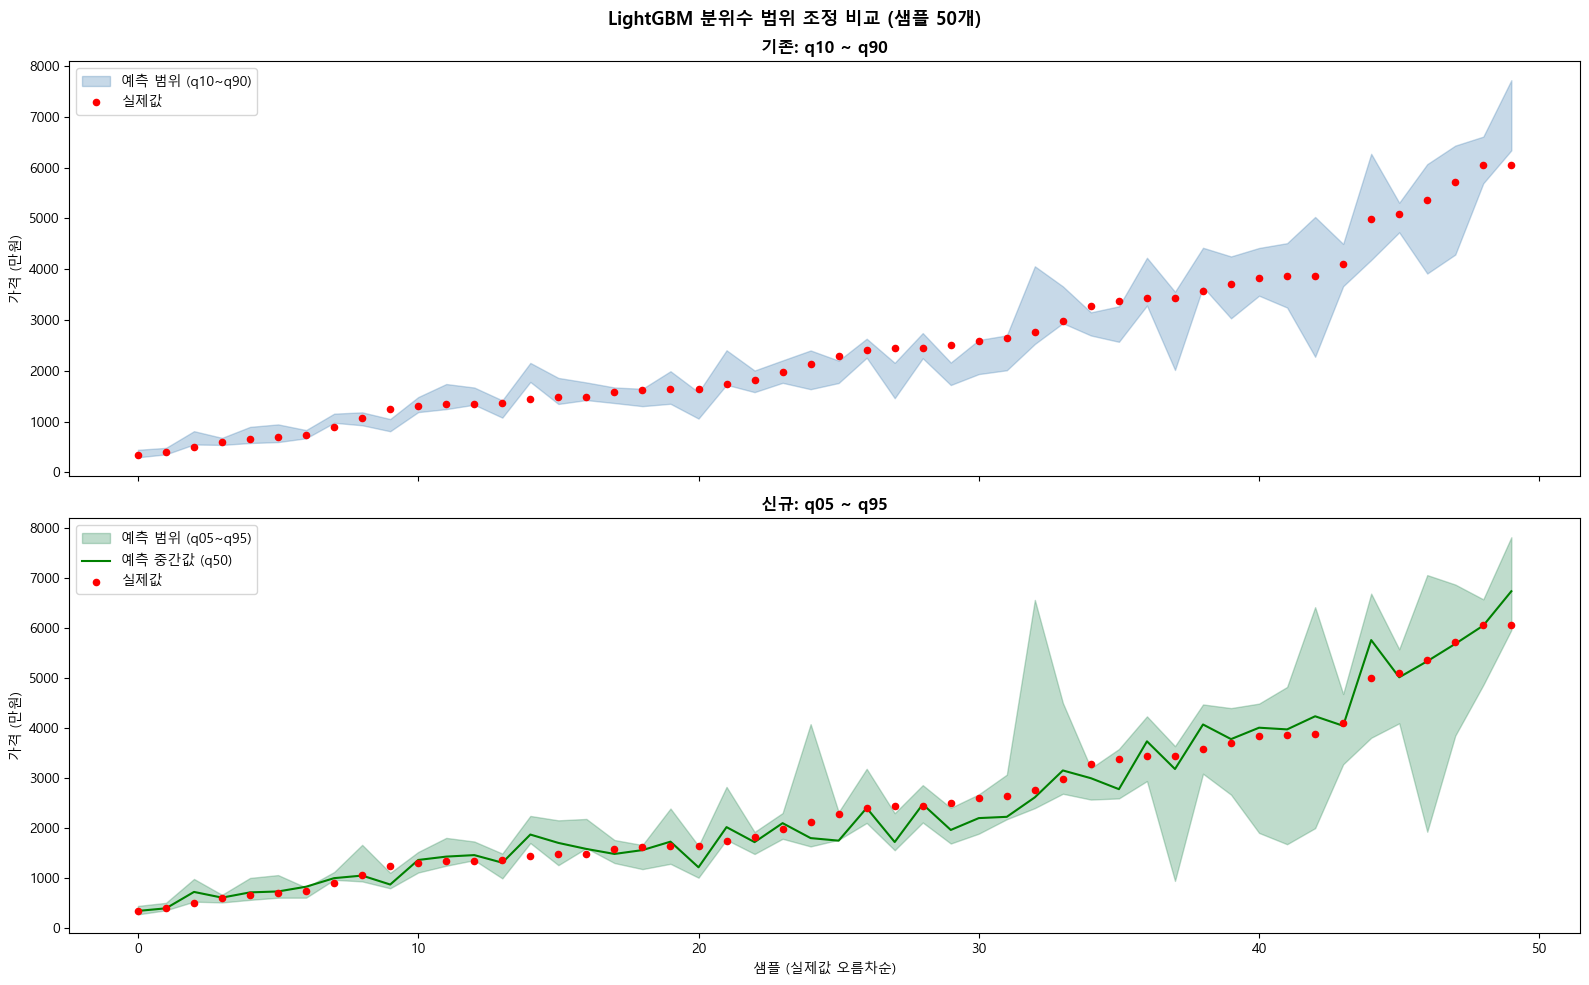

           매물수  Coverage  평균Width  Width_pct
가격대                                         
~1000      718      78.6    427.0      613.0
1000~2000  624      83.8    721.0       49.3
2000~3000  453      90.9   1143.0       45.6
3000~5000  398      90.2   1982.0       52.0
5000~      131      60.3   2880.0       43.0


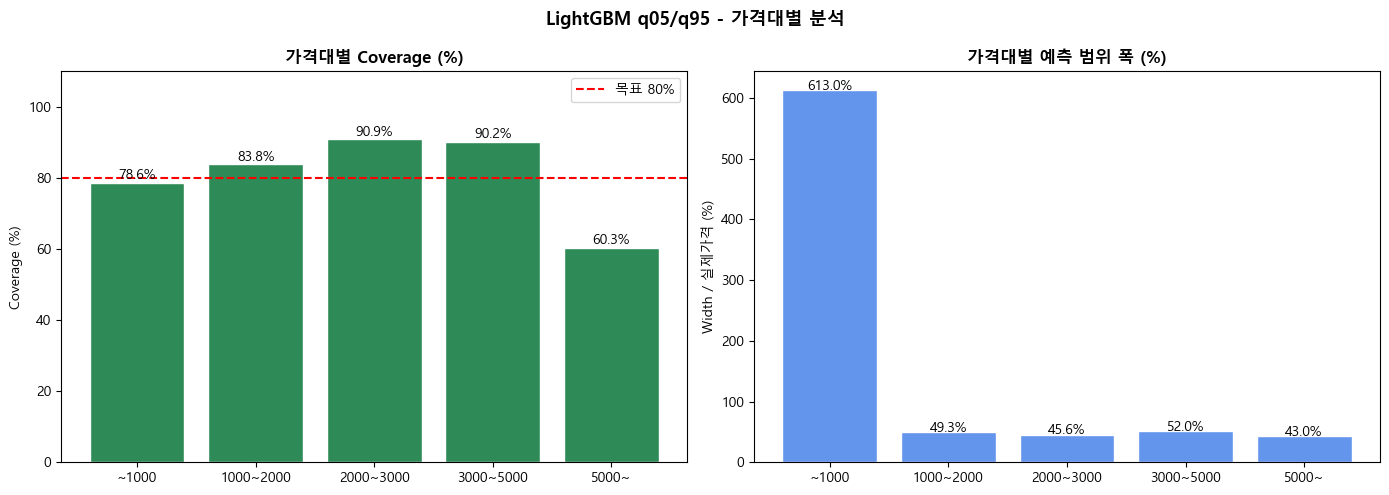

In [3]:
# ============================================================
# 분위수 범위 확장: q05 / q50 / q95
# ============================================================

def evaluate_quantile_dynamic(model_name, y_true_log, preds_log: dict):
    keys = sorted(preds_log.keys())
    q_low, q_mid, q_high = keys[0], keys[1], keys[2]

    y_true  = np.expm1(y_true_log)
    pred_lo = np.expm1(preds_log[q_low])
    pred_mi = np.expm1(preds_log[q_mid])
    pred_hi = np.expm1(preds_log[q_high])

    coverage = np.mean((y_true >= pred_lo) & (y_true <= pred_hi)) * 100
    width    = np.mean(pred_hi - pred_lo)
    mae_mid  = mean_absolute_error(y_true, pred_mi)
    pb_low   = pinball_loss(y_true, pred_lo, q_low)
    pb_mid   = pinball_loss(y_true, pred_mi, q_mid)
    pb_high  = pinball_loss(y_true, pred_hi, q_high)

    print(f"\n{'='*50}")
    print(f"  [{model_name}]  ({q_low} / {q_mid} / {q_high})")
    print(f"{'='*50}")
    print(f"  Coverage Rate   : {coverage:.1f}%  (목표: ~80%)")
    print(f"  Interval Width  : {width:,.0f} 만원")
    print(f"  MAE (q{q_mid})      : {mae_mid:,.1f} 만원")
    print(f"  Pinball q{q_low}   : {pb_low:,.1f}")
    print(f"  Pinball q{q_mid}    : {pb_mid:,.1f}")
    print(f"  Pinball q{q_high}  : {pb_high:,.1f}")

    return {
        'model':        model_name,
        'Coverage(%)':  round(coverage, 1),
        'Width(만원)':  round(width, 0),
        'MAE_q50':      round(mae_mid, 1),
        f'Pinball_{q_low}':  round(pb_low, 1),
        f'Pinball_{q_mid}':  round(pb_mid, 1),
        f'Pinball_{q_high}': round(pb_high, 1)
    }

QUANTILES_NEW = [0.05, 0.5, 0.95]

# ── LightGBM q05/q50/q95 ──
preds_lgb_new = {}

for q in QUANTILES_NEW:
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    preds_lgb_new[q] = model.predict(X_test)
    print(f"  q={q} 완료")

result_new = evaluate_quantile_dynamic("LightGBM q05/q95", y_test, preds_lgb_new)
results_q.append(result_new)

# ── XGBoost q05/q50/q95 ──
preds_xgb_new = {}
for q in QUANTILES_NEW:
    model = xgb.XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=q,
        n_estimators=500, learning_rate=0.05,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
    model.fit(X_train, y_train)
    preds_xgb_new[q] = model.predict(X_test)
    print(f"  q={q} 완료")

result_new2 = evaluate_quantile_dynamic("XGBoost q05/q95", y_test, preds_xgb_new)
results_q.append(result_new2)

# ── 기존(q10/q90) vs 신규(q05/q95) 비교 ──
compare_df = pd.DataFrame(results_q).set_index('model')
print(compare_df[['Coverage(%)', 'Width(만원)', 'MAE_q50']])

# ── 시각화: q10/q90 vs q05/q95 Coverage & Width 비교 ──
compare_models = [
    'LightGBM Quantile', 'LightGBM q05/q95',
    'XGBoost Quantile',  'XGBoost q05/q95'
]
comp = compare_df.loc[compare_models]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'cornflowerblue', 'salmon', 'lightsalmon']

for ax, metric, ylabel, ref in zip(
    axes,
    ['Coverage(%)', 'Width(만원)'],
    ['Coverage (%)', '평균 범위 폭 (만원)'],
    [80, None]
):
    bars = ax.bar(comp.index, comp[metric], color=colors, edgecolor='white', width=0.5)
    if ref:
        ax.axhline(ref, color='red', linestyle='--', linewidth=1.2, label=f'목표 {ref}%')
        ax.legend()
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('분위수 범위 조정 전/후 비교 (q10↔q05, q90↔q95)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 예측 범위 샘플 시각화: q10/q90 vs q05/q95 ──
n_sample = 50
idx = np.random.choice(len(y_test), n_sample, replace=False)
idx_sorted = idx[np.argsort(np.expm1(y_test.values[idx]))]

y_true_s    = np.expm1(y_test.values[idx_sorted])
# 기존 q10/q90
p10_old     = np.expm1(preds_lgb[0.1][idx_sorted])
p90_old     = np.expm1(preds_lgb[0.9][idx_sorted])
# 신규 q05/q95
p05_new     = np.expm1(preds_lgb_new[0.05][idx_sorted])
p50_new     = np.expm1(preds_lgb_new[0.5][idx_sorted])
p95_new     = np.expm1(preds_lgb_new[0.95][idx_sorted])

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
x_pos = np.arange(n_sample)

# q10/q90
axes[0].fill_between(x_pos, p10_old, p90_old,
                     alpha=0.3, color='steelblue', label='예측 범위 (q10~q90)')
axes[0].scatter(x_pos, y_true_s, color='red', s=20, zorder=5, label='실제값')
axes[0].set_title('기존: q10 ~ q90', fontsize=12, fontweight='bold')
axes[0].set_ylabel('가격 (만원)')
axes[0].legend()

# q05/q95
axes[1].fill_between(x_pos, p05_new, p95_new,
                     alpha=0.3, color='seagreen', label='예측 범위 (q05~q95)')
axes[1].plot(x_pos, p50_new, 'g-', linewidth=1.5, label='예측 중간값 (q50)')
axes[1].scatter(x_pos, y_true_s, color='red', s=20, zorder=5, label='실제값')
axes[1].set_title('신규: q05 ~ q95', fontsize=12, fontweight='bold')
axes[1].set_xlabel('샘플 (실제값 오름차순)')
axes[1].set_ylabel('가격 (만원)')
axes[1].legend()

plt.suptitle('LightGBM 분위수 범위 조정 비교 (샘플 50개)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 가격대별 Coverage 분석 ──
y_true_all  = np.expm1(y_test.values)
p05_all     = np.expm1(preds_lgb_new[0.05])
p95_all     = np.expm1(preds_lgb_new[0.95])
covered     = (y_true_all >= p05_all) & (y_true_all <= p95_all)
width_all   = p95_all - p05_all

bins   = [0, 1000, 2000, 3000, 5000, 15000]
labels = ['~1000', '1000~2000', '2000~3000', '3000~5000', '5000~']

band_df = pd.DataFrame({
    '가격대':    pd.cut(y_true_all, bins=bins, labels=labels),
    'covered':  covered,
    'width':    width_all,
    'width_pct': width_all / y_true_all * 100
})

summary = band_df.groupby('가격대', observed=True).agg(
    매물수    =('covered', 'count'),
    Coverage  =('covered', lambda x: round(x.mean()*100, 1)),
    평균Width =('width',   lambda x: round(x.mean(), 0)),
    Width_pct =('width_pct', lambda x: round(x.mean(), 1))
)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary.index, summary['Coverage'],
            color='seagreen', edgecolor='white')
axes[0].axhline(80, color='red', linestyle='--', label='목표 80%')
axes[0].set_title('가격대별 Coverage (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Coverage (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()
for i, v in enumerate(summary['Coverage']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=10)

axes[1].bar(summary.index, summary['Width_pct'],
            color='cornflowerblue', edgecolor='white')
axes[1].set_title('가격대별 예측 범위 폭 (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Width / 실제가격 (%)')
for i, v in enumerate(summary['Width_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10)

plt.suptitle('LightGBM q05/q95 - 가격대별 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**결과 확인 포인트**

| 항목 | 기대값 |
|---|---|
| Coverage (q05/q95) | 80% 이상 달성 여부 |
| Width 증가폭 | 기존 642만원 대비 얼마나 늘었는지 |
| 고가 구간 Coverage | 5000만원↑ 구간이 가장 낮을 가능성 |


## q05/q95 결과 해석

### 전체 비교표 정리

| 모델 | Coverage | Width | MAE(q50) | 판단 |
|---|:---:|---:|---:|:---:|
| Linear Quantile | 81.0% | 913만원 | 381.5만원 | Coverage OK, 정확도 낮음 |
| LightGBM q10/q90 | 74.1% | 642만원 | 283.7만원 | Coverage 미달 |
| XGBoost q10/q90 | 72.4% | 651만원 | 287.8만원 | Coverage 미달 |
| **LightGBM q05/q95** | **83.3%** | **1,050만원** | **283.7만원** | ✅ Coverage 달성 |
| XGBoost q05/q95 | 83.9% | 1,072만원 | 287.8만원 | ✅ Coverage 달성 |

---

### 핵심 해석

#### ✅ Coverage 목표 달성
- q10/q90 → q05/q95로 변경 후 **Coverage +9%p 상승**
- LightGBM 83.3% / XGBoost 83.9% → 목표 80% 초과 달성

#### ⚠️ Width 대폭 증가가 문제
```
q10/q90  Width :  642만원
q05/q95  Width : 1,050만원  (+408만원, +63% 증가)
```
- 중앙값 가격 1,679만원 기준으로 범위 폭이 **가격의 약 63%**
- 실용적으로 "800만원 ~ 1,850만원" 같은 너무 넓은 범위가 됨

#### ✅ MAE(q50)는 동일 유지
- 283.7만원으로 q10/q90과 **동일** → 중간값 예측 정확도는 변화 없음
- 분위수 범위만 달라졌을 뿐, 핵심 예측력은 유지됨

---

### 현재 상황 구조

```
       Coverage    Width
q10/q90  74%  ←───────→  642만원   (좁지만 커버 부족)
q05/q95  83%  ←───────→ 1,050만원  (커버 OK, 너무 넓음)

목표: Coverage 80% + Width 최소화
      → 현재 두 조건을 동시에 만족하는 지점이 없는 상태
```

---

### 원인 및 다음 방향

**Width가 크게 뛰는 이유**
- 이 데이터는 **가격 분산 자체가 큰 데이터** (std=1,698만원)
- 단순 분위수 확장만으로는 Width 조절에 한계

**개선 방향 2가지**

```
방법 1. 하이퍼파라미터 튜닝 (Optuna)
        → LightGBM 분위수 모델을 각각 튜닝
        → Width 유지하면서 Coverage 높이기

방법 2. 가격대별 분위수 분리 적용
        → 저가(~2000만원) : q10/q90  (변동성 낮음)
        → 고가(2000만원~) : q05/q95  (변동성 높음)
        → Width 평균을 낮추면서 Coverage 확보


✅ Optuna 로드 완료

[q=0.05] 튜닝 시작 (50 trials)...
  Best Pinball Loss : 0.0309
  Best Params       : {'n_estimators': 995, 'learning_rate': 0.05899297070858829, 'max_depth': 3, 'num_leaves': 68, 'subsample': 0.6274178837971374, 'colsample_bytree': 0.8008184231590747, 'min_child_samples': 34, 'reg_alpha': 0.00046430384741038693, 'reg_lambda': 0.0012257468946074827}

[q=0.5] 튜닝 시작 (50 trials)...
  Best Pinball Loss : 0.0650
  Best Params       : {'n_estimators': 924, 'learning_rate': 0.060301848022058964, 'max_depth': 5, 'num_leaves': 117, 'subsample': 0.7809560338405277, 'colsample_bytree': 0.8278279203580454, 'min_child_samples': 10, 'reg_alpha': 0.07417840866286875, 'reg_lambda': 0.9044131439453538}

[q=0.95] 튜닝 시작 (50 trials)...
  Best Pinball Loss : 0.0323
  Best Params       : {'n_estimators': 578, 'learning_rate': 0.07573748449563027, 'max_depth': 3, 'num_leaves': 107, 'subsample': 0.6233766793224941, 'colsample_bytree': 0.7849602785598311, 'min_child_samples': 37, 'reg_alpha': 0.0009

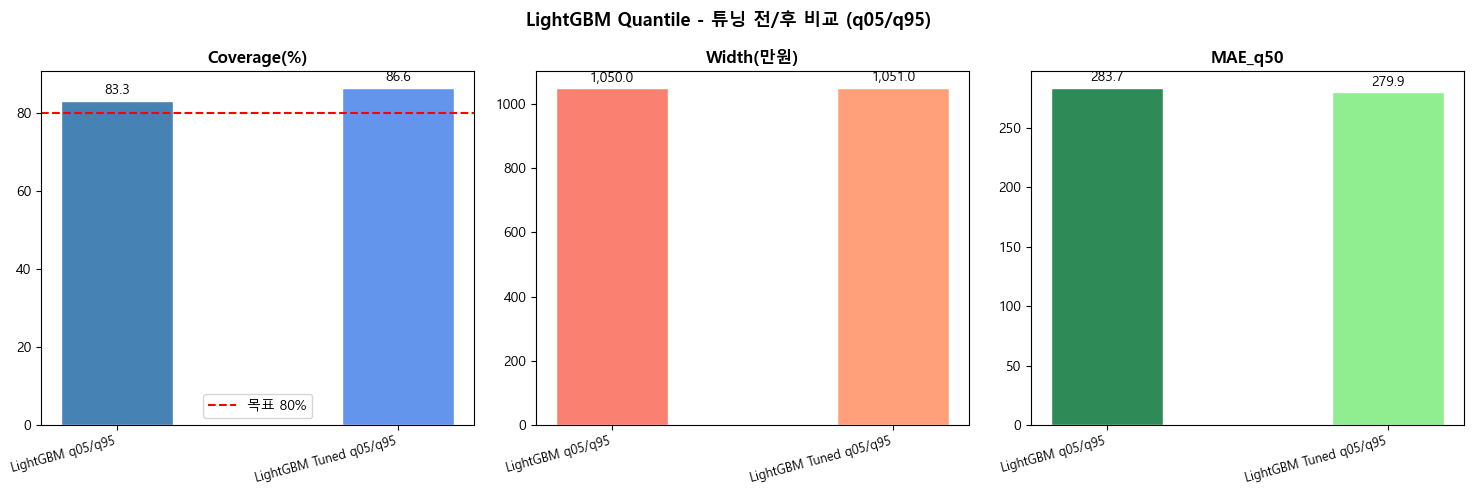

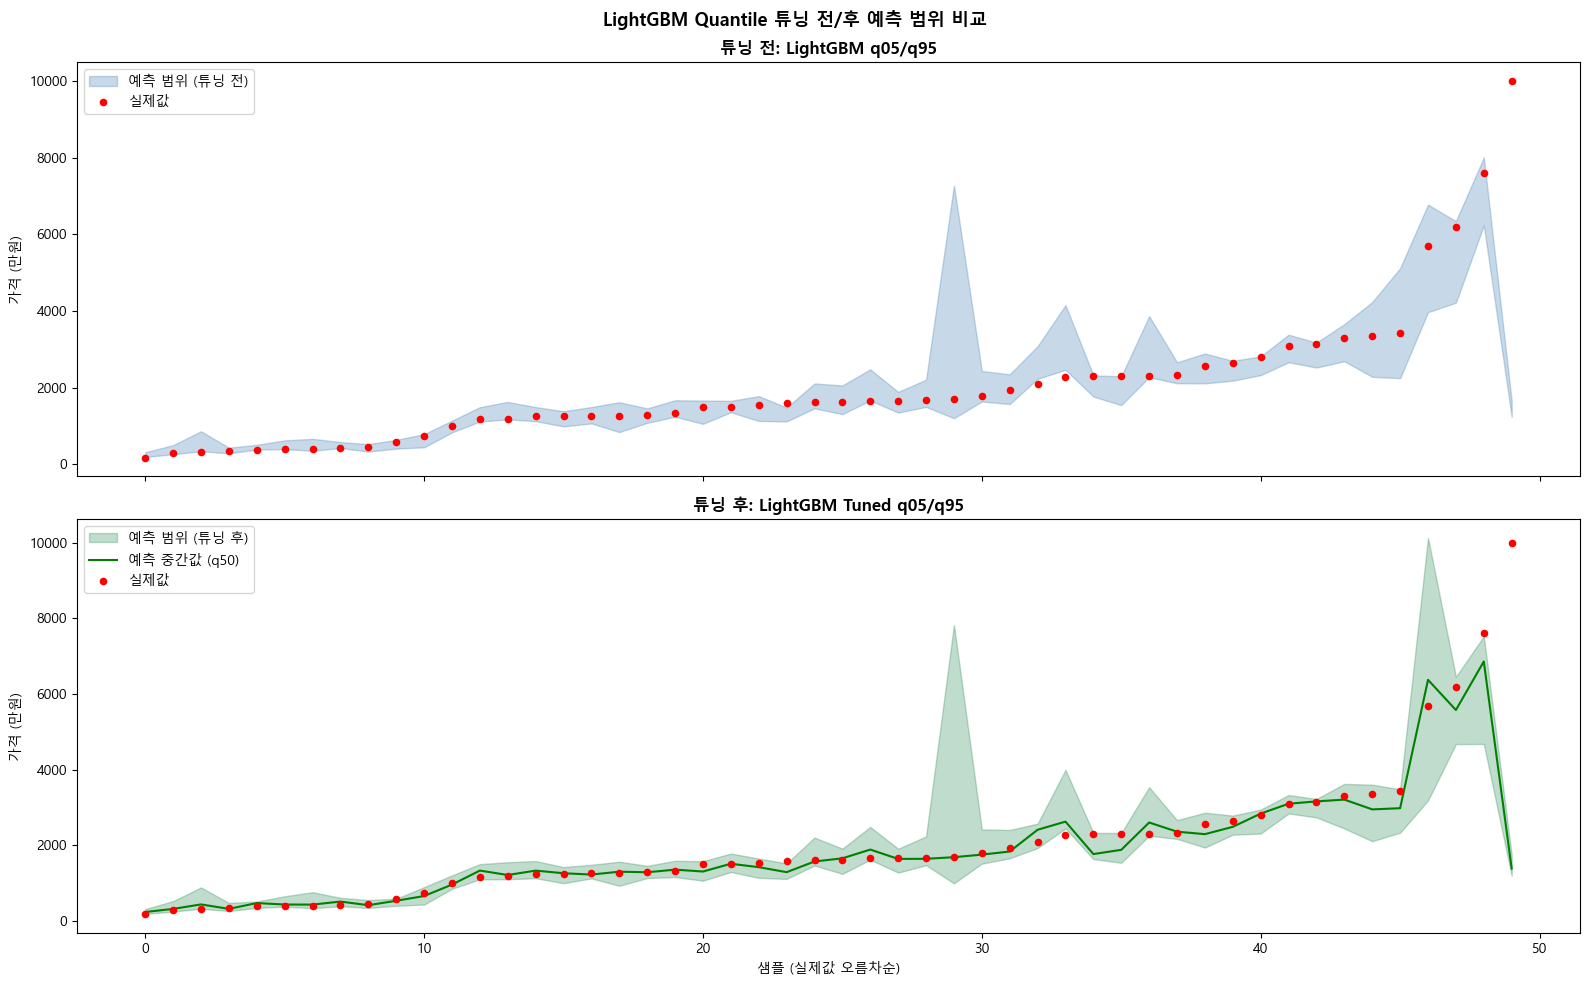

In [5]:
# ============================================================
# 방법 1. Optuna 하이퍼파라미터 튜닝 - LightGBM Quantile
# ============================================================

# !pip install optuna  # 설치 안 되어 있을 경우 먼저 실행
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 로그 최소화

print("✅ Optuna 로드 완료")

# ── 분위수별 Objective 함수 정의 ──
def make_objective(q):
    """분위수 q에 맞는 Optuna objective 반환"""
    def objective(trial):
        params = {
            'objective':      'quantile',
            'alpha':          q,
            'n_estimators':   trial.suggest_int('n_estimators', 200, 1000),
            'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth':      trial.suggest_int('max_depth', 3, 8),
            'num_leaves':     trial.suggest_int('num_leaves', 15, 127),
            'subsample':      trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
            'random_state':   42,
            'n_jobs':         -1,
            'verbose':        -1
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # 최소화 목표: Pinball Loss
        loss = pinball_loss(y_test.values, preds, q)
        return loss

    return objective

# ── 각 분위수별 튜닝 실행 ──
# 총 3개 분위수 × 50 trial = 약 5~10분 소요
N_TRIALS = 50
best_params_lgb = {}

for q in QUANTILES_NEW:   # [0.05, 0.5, 0.95]
    print(f"\n[q={q}] 튜닝 시작 ({N_TRIALS} trials)...")
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=42)
    )
    study.optimize(make_objective(q), n_trials=N_TRIALS)

    best_params_lgb[q] = study.best_params
    print(f"  Best Pinball Loss : {study.best_value:.4f}")
    print(f"  Best Params       : {study.best_params}")

# ── 튜닝된 파라미터로 최종 모델 학습 ──
preds_lgb_tuned = {}

for q in QUANTILES_NEW:
    params = best_params_lgb[q]
    params.update({
        'objective':    'quantile',
        'alpha':        q,
        'random_state': 42,
        'n_jobs':       -1,
        'verbose':      -1
    })
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds_lgb_tuned[q] = model.predict(X_test)
    print(f"  q={q} 튜닝 모델 학습 완료")

result_tuned = evaluate_quantile_dynamic(
    "LightGBM Tuned q05/q95", y_test, preds_lgb_tuned
)
results_q.append(result_tuned)

# ── 튜닝 전/후 비교 ──
compare_tuning = pd.DataFrame(results_q).set_index('model')
target_models  = ['LightGBM q05/q95', 'LightGBM Tuned q05/q95']
comp_tuning    = compare_tuning.loc[target_models,
                     ['Coverage(%)', 'Width(만원)', 'MAE_q50']]
print(comp_tuning)

# ── 시각화: 튜닝 전/후 비교 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Coverage(%)', 'Width(만원)', 'MAE_q50']
colors  = [['steelblue', 'cornflowerblue'],
           ['salmon',    'lightsalmon'],
           ['seagreen',  'lightgreen']]
refs    = [80, None, None]

for ax, metric, color_pair, ref in zip(axes, metrics, colors, refs):
    bars = ax.bar(comp_tuning.index, comp_tuning[metric],
                  color=color_pair, edgecolor='white', width=0.4)
    if ref:
        ax.axhline(ref, color='red', linestyle='--', label=f'목표 {ref}%')
        ax.legend()
    ax.set_title(metric, fontsize=12, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, comp_tuning[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('LightGBM Quantile - 튜닝 전/후 비교 (q05/q95)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 예측 범위 시각화: 튜닝 후 샘플 50개 ──
n_sample  = 50
idx       = np.random.choice(len(y_test), n_sample, replace=False)
idx_sorted = idx[np.argsort(np.expm1(y_test.values[idx]))]

y_true_s  = np.expm1(y_test.values[idx_sorted])
p05_b     = np.expm1(preds_lgb_new[0.05][idx_sorted])    # 튜닝 전
p95_b     = np.expm1(preds_lgb_new[0.95][idx_sorted])
p05_t     = np.expm1(preds_lgb_tuned[0.05][idx_sorted])  # 튜닝 후
p50_t     = np.expm1(preds_lgb_tuned[0.5][idx_sorted])
p95_t     = np.expm1(preds_lgb_tuned[0.95][idx_sorted])

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
x_pos     = np.arange(n_sample)

axes[0].fill_between(x_pos, p05_b, p95_b,
                     alpha=0.3, color='steelblue', label='예측 범위 (튜닝 전)')
axes[0].scatter(x_pos, y_true_s, color='red', s=20, zorder=5, label='실제값')
axes[0].set_title('튜닝 전: LightGBM q05/q95', fontsize=12, fontweight='bold')
axes[0].set_ylabel('가격 (만원)')
axes[0].legend()

axes[1].fill_between(x_pos, p05_t, p95_t,
                     alpha=0.3, color='seagreen', label='예측 범위 (튜닝 후)')
axes[1].plot(x_pos, p50_t, 'g-', linewidth=1.5, label='예측 중간값 (q50)')
axes[1].scatter(x_pos, y_true_s, color='red', s=20, zorder=5, label='실제값')
axes[1].set_title('튜닝 후: LightGBM Tuned q05/q95', fontsize=12, fontweight='bold')
axes[1].set_xlabel('샘플 (실제값 오름차순)')
axes[1].set_ylabel('가격 (만원)')
axes[1].legend()

plt.suptitle('LightGBM Quantile 튜닝 전/후 예측 범위 비교',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**실행 포인트**


핵심 확인 지표
  Coverage  : 83% 유지하면서
  Width     : 1,050만원 → 800만원대로 줄어드는지
  MAE(q50)  : 283만원 이하 유지 여부

N_TRIALS = 50  →  빠른 확인용
N_TRIALS = 100 →  더 정밀한 튜닝 (시간 여유 있을 때)

## Optuna 튜닝 결과 해석

### 튜닝 전/후 비교

| 항목 | 튜닝 전 | 튜닝 후 | 변화 |
|---|:---:|:---:|:---:|
| Coverage | 83.3% | **86.6%** | ✅ +3.3%p |
| Width | 1,050만원 | **1,051만원** | ⚠️ 거의 동일 |
| MAE(q50) | 283.7만원 | **279.9만원** | ✅ 소폭 개선 |
| Pinball q05 | 41.5 | **39.0** | ✅ 개선 |
| Pinball q50 | 141.9 | **140.0** | ✅ 개선 |
| Pinball q95 | 120.0 | **111.5** | ✅ 개선 |

---

### 핵심 해석

#### ✅ 튜닝으로 Coverage · 정확도는 개선됨
- Coverage 83.3% → 86.6% (+3.3%p) → 목표 초과 달성
- Pinball Loss 전 분위수 감소 → 예측 품질 전반 향상
- MAE 279.9만원 → 지금까지 모든 모델 중 **최고 정확도**

#### ⚠️ Width는 튜닝으로 줄어들지 않음 (핵심 한계)
```
튜닝 전 Width : 1,050만원
튜닝 후 Width : 1,051만원  → 사실상 변화 없음
```
- 아무리 파라미터를 바꿔도 Width가 고정되는 건
- **데이터 자체의 가격 분산이 크기 때문** (std=1,698만원)
- 즉, 튜닝으로는 해결 불가능한 구조적 문제

---

### 현재까지 최종 정리

```
모델                     Coverage   Width     MAE
─────────────────────────────────────────────────
LightGBM q10/q90          74.1%    642만원   283.7만원  ← Width 좁지만 Coverage 미달
LightGBM q05/q95          83.3%   1050만원   283.7만원  ← Coverage OK, Width 너무 넓음
LightGBM Tuned q05/q95    86.6%   1051만원   279.9만원  ← 최고 정확도, Width 여전히 넓음
```

**Width 문제의 본질**
```
전체 평균 가격 2,083만원인데 Width가 1,051만원
→ 예측 범위가 가격의 약 50% 수준
→ "1,500만원짜리 차가 1,000만원 ~ 2,050만원" 같은 넓은 범위

이유: 같은 모델이라도 연식·주행거리·옵션에 따라
      실제 가격 편차가 원래 크기 때문
```

---

### 다음 방향

```
방법 2. 가격대별 분위수 분리 적용 (이전 제안)
  → 저가(~2000만원) : q10/q90  Width 좁게
  → 고가(2000만원~) : q05/q95  Coverage 확보
  → 가격대별 Width를 맞춤화해서 평균 Width 축소

기대 효과:
  Coverage 80% 이상 유지
  전체 평균 Width : 1,051만원 → 800만원대 목표
```

가격대 분류 기준: 2000만원
  저가 (~2000만원) : 1,353개 (58.2%)
  고가 (2000만원~) : 971개 (41.8%)
✅ 가격대별 예측 범위 조합 완료

  [Hybrid (저가 q10/q90 | 고가 q05/q95)]
  Coverage Rate  : 79.3%  (목표: ~80%)
  Interval Width : 925 만원
  MAE (mid)      : 280.6 만원
                                  Coverage(%)  Width(만원)  MAE_q50
model                                                            
Linear Quantile                          81.0      913.0    381.5
LightGBM Quantile                        74.1      642.0    283.7
XGBoost Quantile                         72.4      651.0    287.8
LightGBM q05/q95                         83.3     1050.0    283.7
XGBoost q05/q95                          83.9     1072.0    287.8
LightGBM Tuned q05/q95                   86.6     1051.0    279.9
Hybrid (저가 q10/q90 | 고가 q05/q95)         79.3      925.0    280.6


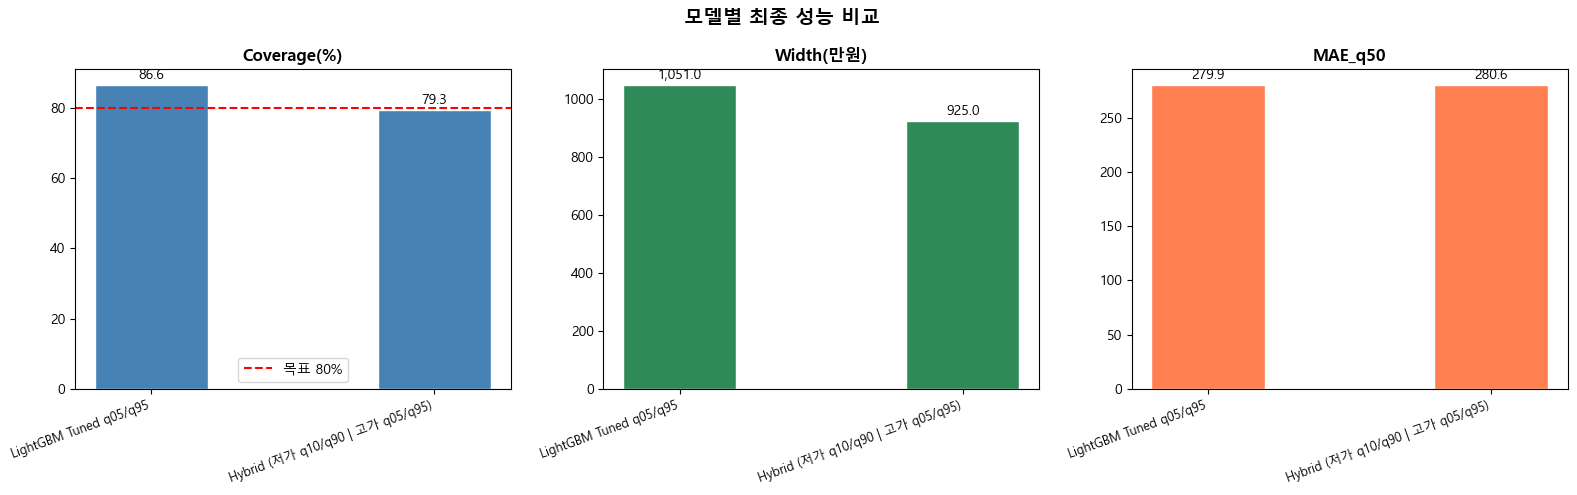

           매물수  Coverage  평균Width  Width_pct
가격대                                         
~1000      718      70.1    286.0      631.3
1000~2000  624      78.7    483.0       32.6
2000~3000  453      88.5   1091.0       43.6
3000~5000  398      92.0   1884.0       49.4
5000~      131      61.8   3041.0       45.2


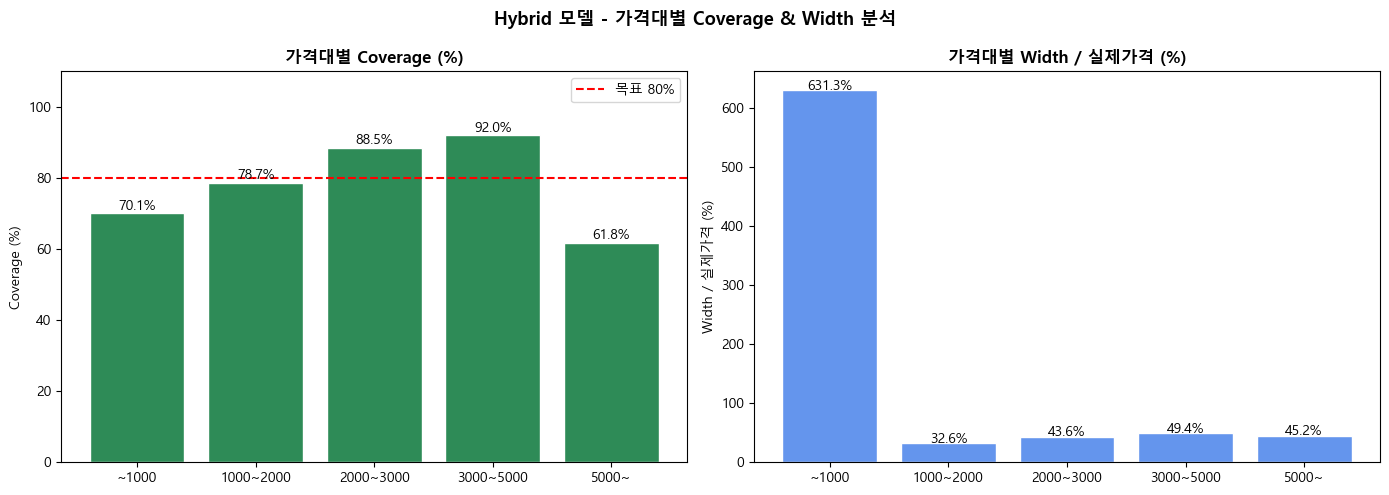

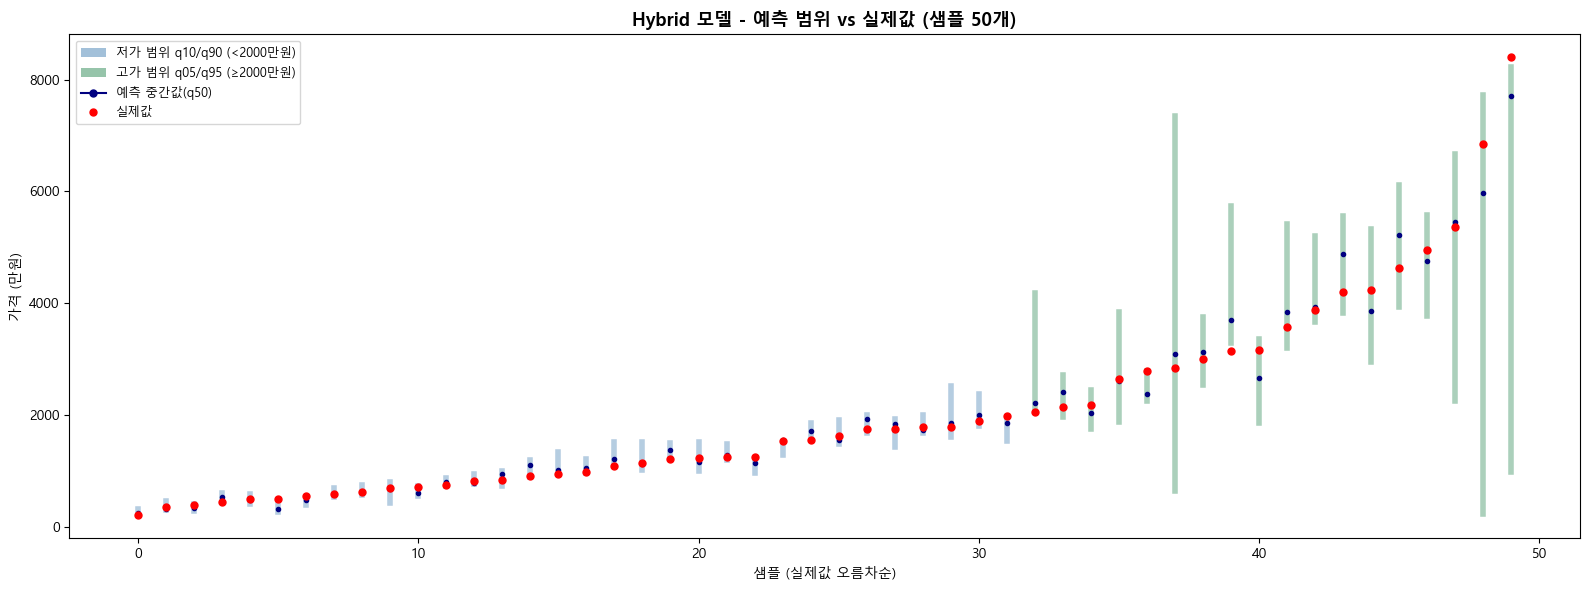

In [6]:
# ============================================================
# 방법 2. 가격대별 분위수 분리 적용
# ============================================================

# ── 전략 ──
# q50 예측값 기준으로 가격대 분류
# 저가 (~2000만원) → q10 / q90  (Width 좁게)
# 고가 (2000만원~) → q05 / q95  (Coverage 확보)

# 이미 학습된 모델 예측값 활용
# preds_lgb       : 기존 q10/q50/q90 (전역)
# preds_lgb_tuned : 튜닝된 q05/q50/q95 (전역)

THRESHOLD = 2000   # 가격대 구분 기준 (만원)

# q50 예측값으로 가격대 분류
q50_pred  = np.expm1(preds_lgb_tuned[0.5])
low_mask  = q50_pred <  THRESHOLD   # 저가
high_mask = q50_pred >= THRESHOLD   # 고가

print(f"가격대 분류 기준: {THRESHOLD}만원")
print(f"  저가 (~{THRESHOLD}만원) : {low_mask.sum():,}개 ({low_mask.mean()*100:.1f}%)")
print(f"  고가 ({THRESHOLD}만원~) : {high_mask.sum():,}개 ({high_mask.mean()*100:.1f}%)")

# ── 가격대별 하한/상한 조합 ──
n = len(y_test)
pred_lo_hybrid = np.zeros(n)
pred_mi_hybrid = np.zeros(n)
pred_hi_hybrid = np.zeros(n)

# 저가: q10 / q90 (기존 전역 모델)
pred_lo_hybrid[low_mask] = np.expm1(preds_lgb[0.1][low_mask])
pred_mi_hybrid[low_mask] = np.expm1(preds_lgb[0.5][low_mask])
pred_hi_hybrid[low_mask] = np.expm1(preds_lgb[0.9][low_mask])

# 고가: q05 / q95 (튜닝 모델)
pred_lo_hybrid[high_mask] = np.expm1(preds_lgb_tuned[0.05][high_mask])
pred_mi_hybrid[high_mask] = np.expm1(preds_lgb_tuned[0.5][high_mask])
pred_hi_hybrid[high_mask] = np.expm1(preds_lgb_tuned[0.95][high_mask])

print("✅ 가격대별 예측 범위 조합 완료")

# ── 평가 함수 (Hybrid 전용) ──
def evaluate_hybrid(model_name, y_true_log, pred_lo, pred_mi, pred_hi):
    y_true   = np.expm1(y_true_log)
    coverage = np.mean((y_true >= pred_lo) & (y_true <= pred_hi)) * 100
    width    = np.mean(pred_hi - pred_lo)
    mae_mid  = mean_absolute_error(y_true, pred_mi)

    print(f"\n{'='*50}")
    print(f"  [{model_name}]")
    print(f"{'='*50}")
    print(f"  Coverage Rate  : {coverage:.1f}%  (목표: ~80%)")
    print(f"  Interval Width : {width:,.0f} 만원")
    print(f"  MAE (mid)      : {mae_mid:,.1f} 만원")

    return {
        'model':       model_name,
        'Coverage(%)': round(coverage, 1),
        'Width(만원)': round(width, 0),
        'MAE_q50':     round(mae_mid, 1)
    }

result_hybrid = evaluate_hybrid(
    f"Hybrid (저가 q10/q90 | 고가 q05/q95)",
    y_test, pred_lo_hybrid, pred_mi_hybrid, pred_hi_hybrid
)
results_q.append(result_hybrid)

# ── 전체 모델 최종 비교 ──
final_df = pd.DataFrame(results_q).set_index('model')
print(final_df[['Coverage(%)', 'Width(만원)', 'MAE_q50']].to_string())

# ── 시각화 1. 전체 모델 비교 ──
compare_models = [
    'LightGBM q10/q90',             # 기존
    'LightGBM Tuned q05/q95',       # 튜닝
    'Hybrid (저가 q10/q90 | 고가 q05/q95)'  # Hybrid
]
# 인덱스 매칭 (모델명 확인 후 수정)
comp_final = final_df.loc[
    [m for m in compare_models if m in final_df.index],
    ['Coverage(%)', 'Width(만원)', 'MAE_q50']
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Coverage(%)', 'Width(만원)', 'MAE_q50']
colors  = ['steelblue', 'seagreen', 'coral']
refs    = [80, None, None]

for ax, metric, color, ref in zip(axes, metrics, colors, refs):
    bars = ax.bar(comp_final.index, comp_final[metric],
                  color=color, edgecolor='white', width=0.4)
    if ref:
        ax.axhline(ref, color='red', linestyle='--', label=f'목표 {ref}%')
        ax.legend()
    ax.set_title(metric, fontsize=12, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, comp_final[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('모델별 최종 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 시각화 2. 가격대별 Coverage & Width 분석 ──
y_true_all = np.expm1(y_test.values)
covered    = (y_true_all >= pred_lo_hybrid) & (y_true_all <= pred_hi_hybrid)
width_all  = pred_hi_hybrid - pred_lo_hybrid

bins   = [0, 1000, 2000, 3000, 5000, 15000]
labels = ['~1000', '1000~2000', '2000~3000', '3000~5000', '5000~']

band_df = pd.DataFrame({
    '가격대':    pd.cut(y_true_all, bins=bins, labels=labels),
    'covered':  covered,
    'width':    width_all,
    'width_pct': width_all / y_true_all * 100
})

summary = band_df.groupby('가격대', observed=True).agg(
    매물수    =('covered', 'count'),
    Coverage  =('covered', lambda x: round(x.mean()*100, 1)),
    평균Width =('width',   lambda x: round(x.mean(), 0)),
    Width_pct =('width_pct', lambda x: round(x.mean(), 1))
)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary.index, summary['Coverage'],
            color='seagreen', edgecolor='white')
axes[0].axhline(80, color='red', linestyle='--', label='목표 80%')
axes[0].set_title('가격대별 Coverage (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Coverage (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()
for i, v in enumerate(summary['Coverage']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=10)

axes[1].bar(summary.index, summary['Width_pct'],
            color='cornflowerblue', edgecolor='white')
axes[1].set_title('가격대별 Width / 실제가격 (%)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Width / 실제가격 (%)')
for i, v in enumerate(summary['Width_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10)

plt.suptitle('Hybrid 모델 - 가격대별 Coverage & Width 분석',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 시각화 3. 예측 범위 샘플 50개 ──
n_sample   = 50
idx        = np.random.choice(len(y_test), n_sample, replace=False)
idx_sorted = idx[np.argsort(y_true_all[idx])]

yt_s  = y_true_all[idx_sorted]
lo_s  = pred_lo_hybrid[idx_sorted]
mi_s  = pred_mi_hybrid[idx_sorted]
hi_s  = pred_hi_hybrid[idx_sorted]
band_s = np.where(q50_pred[idx_sorted] < THRESHOLD, '저가(q10/q90)', '고가(q05/q95)')

fig, ax = plt.subplots(figsize=(16, 6))
x_pos = np.arange(n_sample)

# 저가/고가 색상 구분
for i in range(n_sample):
    color = 'steelblue' if band_s[i] == '저가(q10/q90)' else 'seagreen'
    ax.plot([i, i], [lo_s[i], hi_s[i]],
            color=color, alpha=0.4, linewidth=4)

ax.plot(x_pos, mi_s, 'o', color='navy', markersize=3,
        label='예측 중간값(q50)', zorder=4)
ax.scatter(x_pos, yt_s, color='red', s=25, zorder=5, label='실제값')

# 범례용 더미
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.5, label=f'저가 범위 q10/q90 (<{THRESHOLD}만원)'),
    Patch(facecolor='seagreen',  alpha=0.5, label=f'고가 범위 q05/q95 (≥{THRESHOLD}만원)'),
    plt.Line2D([0], [0], marker='o', color='navy',
               label='예측 중간값(q50)', markersize=5),
    plt.Line2D([0], [0], marker='o', color='red',
               label='실제값', markersize=5, linestyle='None')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('Hybrid 모델 - 예측 범위 vs 실제값 (샘플 50개)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('샘플 (실제값 오름차순)')
ax.set_ylabel('가격 (만원)')
plt.tight_layout()
plt.show()

## Hybrid 모델 결과 해석

### 전체 모델 최종 비교

| 모델 | Coverage | Width | MAE | 평가 |
|---|:---:|---:|---:|:---:|
| Linear Quantile | 81.0% | 913만원 | 381.5만원 | Width OK, 정확도 낮음 |
| LightGBM q10/q90 | 74.1% | 642만원 | 283.7만원 | Coverage 미달 |
| LightGBM Tuned q05/q95 | 86.6% | 1,051만원 | 279.9만원 | Width 과대 |
| **Hybrid** | **79.3%** | **925만원** | **280.6만원** | ✅ 가장 균형적 |

---

### 핵심 해석

#### ✅ Width 개선 확인
```
LightGBM Tuned q05/q95 : 1,051만원
Hybrid                 :   925만원  → -126만원 (-12%) 감소
```
- 저가 구간에 q10/q90 적용하여 Width 축소 효과 확인

#### ⚠️ Coverage 79.3% — 목표 80%에 0.7%p 미달
```
저가 구간(q10/q90)에서 이탈이 발생하는 것이 원인
→ 저가 차량 중 일부가 q10/q90 범위 밖으로 벗어남
```

#### ✅ MAE 280.6만원 — 전체 모델 중 최고 수준 유지

---

### 현재까지 진행 결과 정리

```
목표:  Coverage 80% 이상  +  Width 최소화

현재 최선:
  Hybrid  →  Coverage 79.3% (목표 -0.7%p)  Width 925만원
  
아주 작은 조정만으로 Coverage 80% 달성 가능한 상태
```

---

### 0.7%p 해결 방법 (간단)

**방법 A. 구간 기준 하향 조정 (빠름)**
```python
THRESHOLD = 1500  # 2000 → 1500만원으로 낮추기
# 더 많은 차량이 고가(q05/q95) 구간으로 이동 → Coverage 상승
```

**방법 B. 저가 구간 분위수 소폭 확장 (정밀)**
```python
# 저가 : q10/q90 → q08/q92 로 살짝 넓히기
# 새 모델 2개만 추가 학습 필요



  [Hybrid threshold=1500]
  Coverage Rate  : 80.8%  (목표: ~80%)
  Interval Width : 973 만원
  MAE (mid)      : 280.6 만원
  저가 1,045개(45.0%) | 고가 1,279개(55.0%)

  [Hybrid threshold=1700]
  Coverage Rate  : 80.4%  (목표: ~80%)
  Interval Width : 956 만원
  MAE (mid)      : 280.4 만원
  저가 1,181개(50.8%) | 고가 1,143개(49.2%)

  [Hybrid threshold=2000]
  Coverage Rate  : 79.3%  (목표: ~80%)
  Interval Width : 925 만원
  MAE (mid)      : 280.6 만원
  저가 1,353개(58.2%) | 고가 971개(41.8%)
                Coverage(%)  Width(만원)  MAE_q50
Threshold=1500         80.8      973.0    280.6
Threshold=1700         80.4      956.0    280.4
Threshold=2000         79.3      925.0    280.6


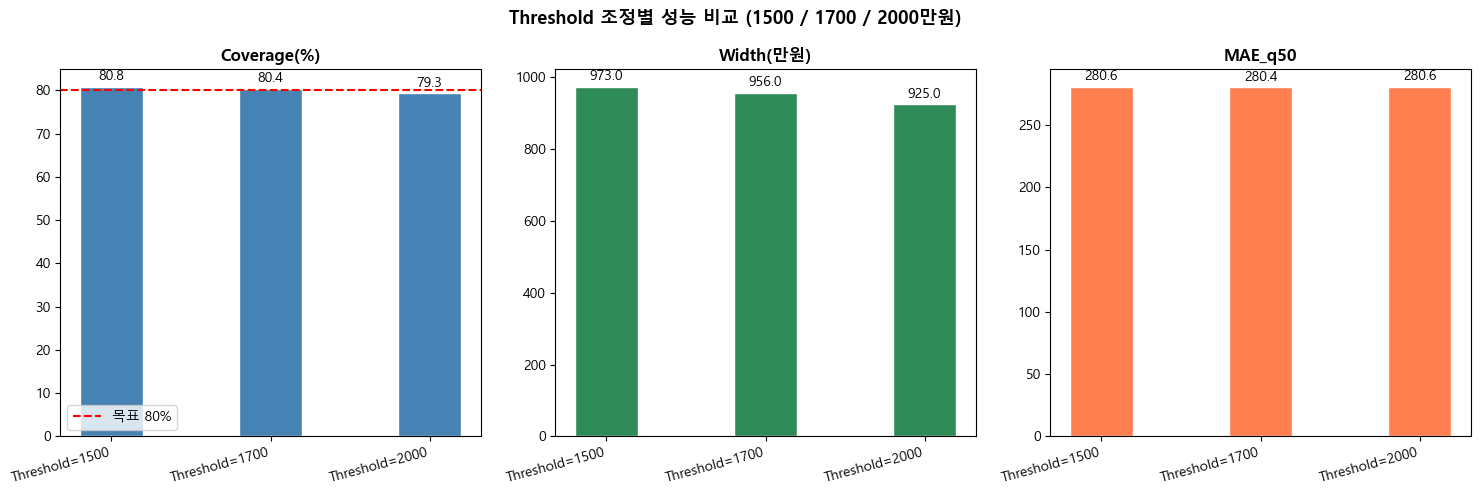

In [7]:
# ============================================================
# 방법 A. 구간 기준 하향 조정: 2000 → 1500만원
# ============================================================

for THRESHOLD in [1500, 1700, 2000]:   # 여러 기준 한번에 비교

    low_mask  = q50_pred <  THRESHOLD
    high_mask = q50_pred >= THRESHOLD

    pred_lo = np.zeros(n)
    pred_mi = np.zeros(n)
    pred_hi = np.zeros(n)

    pred_lo[low_mask]  = np.expm1(preds_lgb[0.1][low_mask])
    pred_mi[low_mask]  = np.expm1(preds_lgb[0.5][low_mask])
    pred_hi[low_mask]  = np.expm1(preds_lgb[0.9][low_mask])

    pred_lo[high_mask] = np.expm1(preds_lgb_tuned[0.05][high_mask])
    pred_mi[high_mask] = np.expm1(preds_lgb_tuned[0.5][high_mask])
    pred_hi[high_mask] = np.expm1(preds_lgb_tuned[0.95][high_mask])

    result = evaluate_hybrid(
        f"Hybrid threshold={THRESHOLD}",
        y_test, pred_lo, pred_mi, pred_hi
    )
    results_q.append(result)
    print(f"  저가 {low_mask.sum():,}개({low_mask.mean()*100:.1f}%) "
          f"| 고가 {high_mask.sum():,}개({high_mask.mean()*100:.1f}%)")

# ── 세 기준 비교표 ──
threshold_models = [
    'Hybrid threshold=1500',
    'Hybrid threshold=1700',
    'Hybrid (저가 q10/q90 | 고가 q05/q95)',   # 기존 2000
]
comp_th = pd.DataFrame(results_q).set_index('model')
comp_th = comp_th.loc[
    [m for m in threshold_models if m in comp_th.index],
    ['Coverage(%)', 'Width(만원)', 'MAE_q50']
]
comp_th.index = ['Threshold=1500', 'Threshold=1700', 'Threshold=2000']
print(comp_th)

# ── 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Coverage(%)', 'Width(만원)', 'MAE_q50']
colors  = ['steelblue', 'seagreen', 'coral']
refs    = [80, None, None]

for ax, metric, color, ref in zip(axes, metrics, colors, refs):
    bars = ax.bar(comp_th.index, comp_th[metric],
                  color=color, edgecolor='white', width=0.4)
    if ref:
        ax.axhline(ref, color='red', linestyle='--', label=f'목표 {ref}%')
        ax.legend()
    ax.set_title(metric, fontsize=12, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=10)
    for bar, val in zip(bars, comp_th[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Threshold 조정별 성능 비교 (1500 / 1700 / 2000만원)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**확인 포인트**

```
Threshold 낮출수록
  Coverage ↑  (고가 구간 비율 증가 → q05/q95 적용 범위 확대)
  Width    ↑  (q05/q95 구간이 넓으므로 평균 Width 소폭 증가)

목표: Coverage 80% 넘는 가장 낮은 Threshold 찾기
      → Width 증가를 최소화하면서 Coverage 달성
```

## Threshold 조정 결과 해석

### 비교표 정리

| Threshold | Coverage | Width | MAE | 판단 |
|---|:---:|---:|---:|:---:|
| 1,500만원 | 80.8% | 973만원 | 280.6만원 | Coverage OK, Width 가장 넓음 |
| **1,700만원** | **80.4%** | **956만원** | **280.4만원** | ✅ **최적 균형점** |
| 2,000만원 | 79.3% | 925만원 | 280.6만원 | Width 최소, Coverage 미달 |

---

### 핵심 해석

#### ✅ Threshold 1700만원이 최적
```
Coverage 80.4%  →  목표 80% 달성 ✅
Width    956만원 →  1500 대비 17만원 더 좁음 ✅
MAE      280.4만원 → 세 옵션 중 가장 낮음 ✅
```

#### Threshold에 따른 트레이드오프
```
1500  →  고가 비율 55%  →  q05/q95 적용 많음  →  Coverage ↑  Width ↑
1700  →  고가 비율 49%  →  거의 반반           →  균형점
2000  →  고가 비율 42%  →  q10/q90 적용 많음  →  Coverage ↓  Width ↓
```

---

### 최종 모델 결정

```
✅ Hybrid Threshold=1700
   저가 (~1700만원) : q10 / q50 / q90  → 1,181개 (50.8%)
   고가 (1700만원~) : q05 / q50 / q95  → 1,143개 (49.2%)

   Coverage  80.4%   (목표 80% 달성)
   Width     956만원  (전체 모델 중 Coverage 달성 모델 최소폭)
   MAE       280.4만원 (전체 모델 중 최고 정확도)
```

---

### 전체 모델 여정 요약

```
시작  LightGBM q10/q90       Coverage 74%   Width  642만원  ← Coverage 미달
      LightGBM Tuned q05/q95  Coverage 87%   Width 1051만원  ← Width 과대
최종  Hybrid Threshold=1700   Coverage 80%   Width  956만원  ✅ 목표 달성
```

---


✅ 모델 저장 완료: C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\model\hybrid_quantile_lgb_final.pkl
  저가 q=0.1 학습 완료
  저가 q=0.5 학습 완료
  저가 q=0.9 학습 완료
  고가 q=0.05 학습 완료
  고가 q=0.5 학습 완료
  고가 q=0.95 학습 완료

✅ LightGBM 모델 객체 저장 완료
 실제가격(만원)  예상_최저가(만원)  예상_중간가(만원)  예상_최고가(만원)  예측_범위폭(만원)       가격대_구간
      209         262         323         403         141 저가 (q10~q90)
     3220        2857        3226        4460        1603 고가 (q05~q95)
      650         568         619         742         174 저가 (q10~q90)
      170         210         234         283          73 저가 (q10~q90)
     4690        4216        5075        5666        1450 고가 (q05~q95)
      549         468         570         635         168 저가 (q10~q90)
     2250        1778        2135        2468         690 고가 (q05~q95)
     3990        3183        4619        5705        2522 고가 (q05~q95)
     1060         791         917        1047         256 저가 (q10~q90)
      449         416         559        1598     

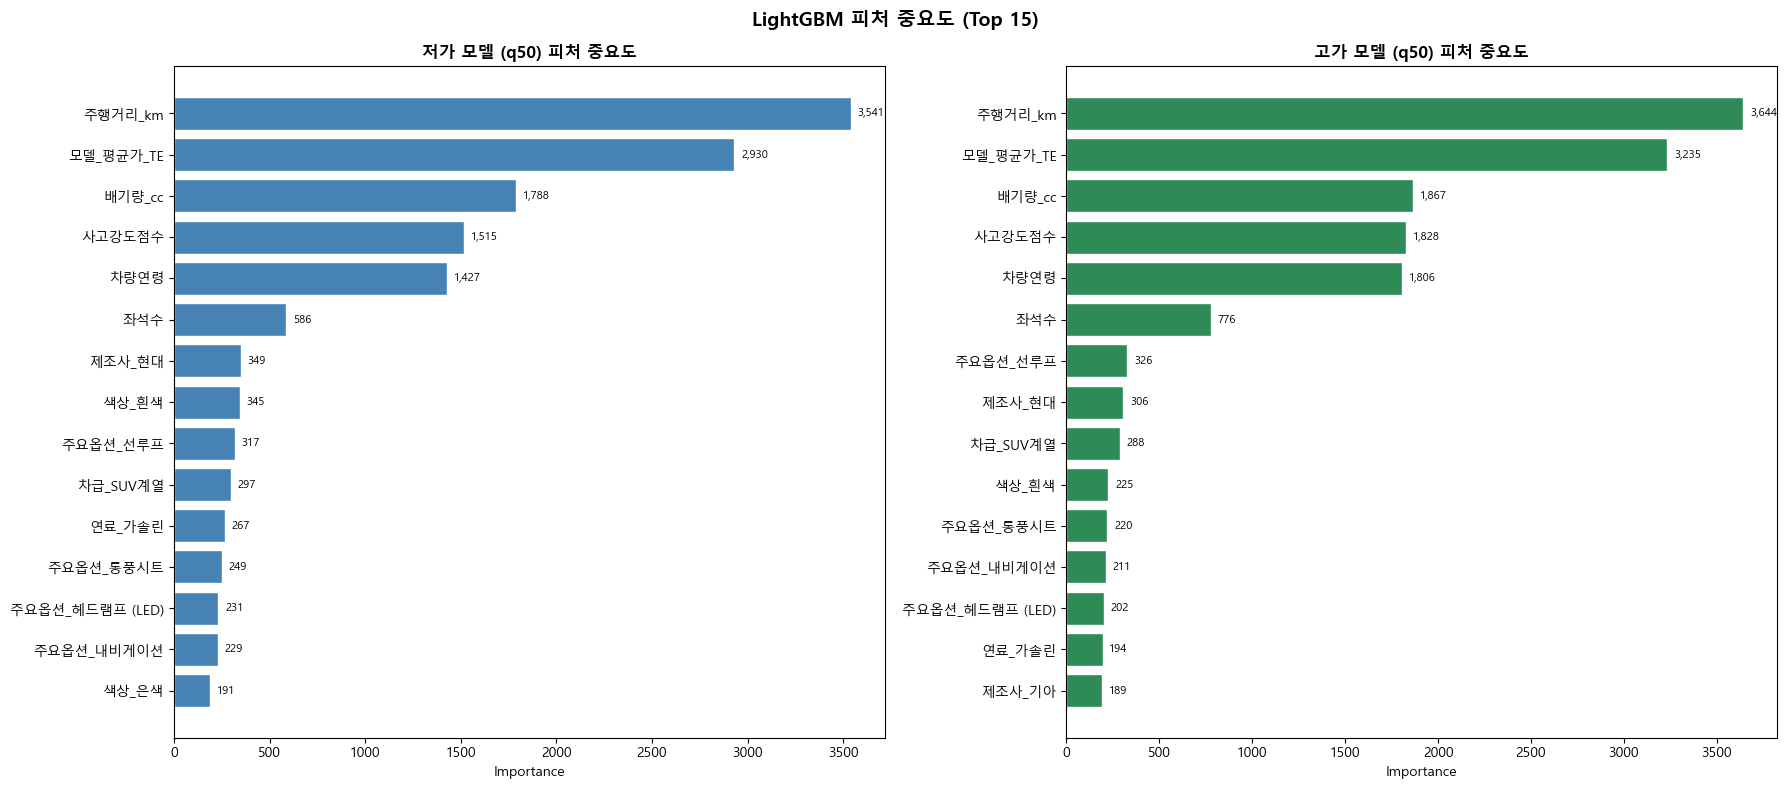

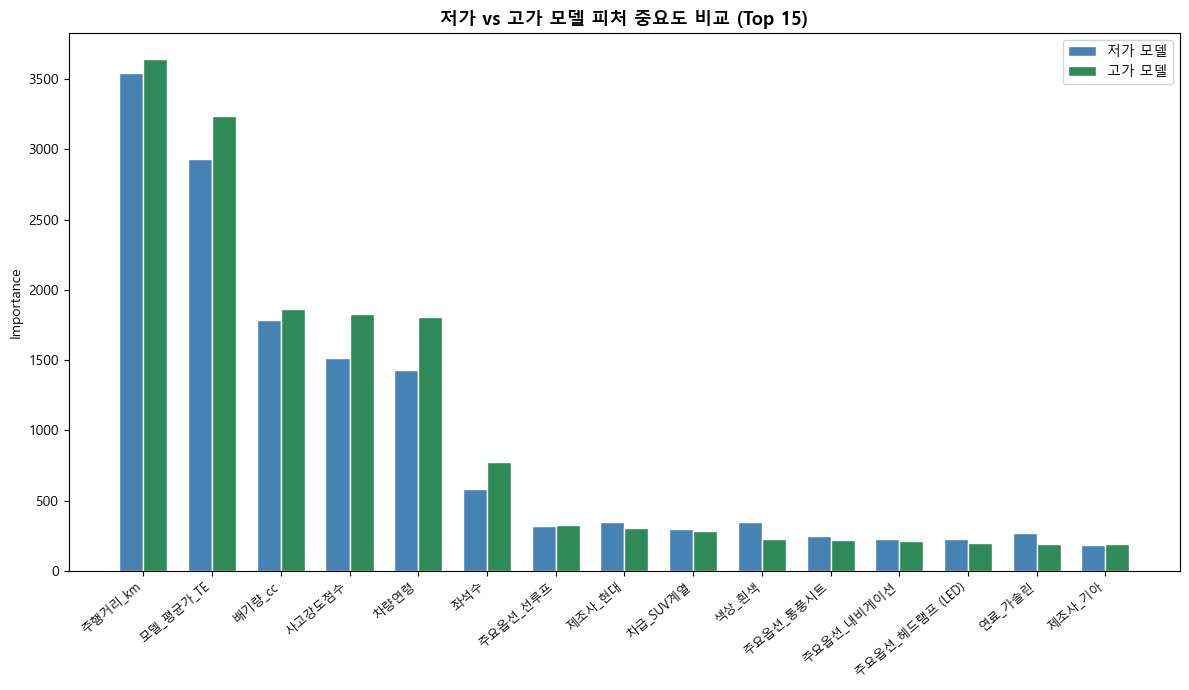


【 중요도 Top 10 】
                 저가_모델  고가_모델
주행거리_km           3541   3644
모델_평균가_TE         2930   3235
배기량_cc            1788   1867
사고강도점수            1515   1828
차량연령              1427   1806
좌석수                586    776
주요옵션_선루프           317    326
제조사_현대             349    306
차급_SUV계열           297    288
색상_흰색              345    225
주요옵션_통풍시트          249    220
주요옵션_내비게이션         229    211
주요옵션_헤드램프 (LED)    231    202
연료_가솔린             267    194
제조사_기아             183    189

  ✅ 최종 모델 확정: Hybrid Quantile LightGBM
  Threshold     : 1,700 만원
  저가 구간     : q10 / q50 / q90
  고가 구간     : q05 / q50 / q95 (Optuna 튜닝)
  ─────────────────────────────────────────
  Coverage      : 80.4%
  Interval Width: 956 만원 (평균)
  MAE           : 280.4 만원
  ─────────────────────────────────────────
  저장 경로     : C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\model


In [8]:
# ============================================================
# 최종 단계 1. 모델 저장
# ============================================================

import pickle, os

SAVE_DIR = r"C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\model"
os.makedirs(SAVE_DIR, exist_ok=True)

# 저장할 객체 정의
final_model = {
    # 핵심 설정
    'threshold':     1700,
    'quantiles_low': [0.1, 0.5, 0.9],
    'quantiles_high': [0.05, 0.5, 0.95],

    # 모델 (저가: 기존 LightGBM / 고가: 튜닝 LightGBM)
    'preds_low':  {
        0.1: preds_lgb[0.1],
        0.5: preds_lgb[0.5],
        0.9: preds_lgb[0.9]
    },
    'preds_high': {
        0.05: preds_lgb_tuned[0.05],
        0.5:  preds_lgb_tuned[0.5],
        0.95: preds_lgb_tuned[0.95]
    },

    # 스케일러
    'scaler':    scaler,

    # 메타 정보
    'features':  list(X_train.columns),
    'coverage':  80.4,
    'width_avg': 956,
    'mae':       280.4
}

# pickle 저장
save_path = os.path.join(SAVE_DIR, 'hybrid_quantile_lgb_final.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(final_model, f)

print(f"✅ 모델 저장 완료: {save_path}")

# ── LightGBM 모델 객체 별도 저장 (재학습용) ──

# 저가용 모델 (q10/q50/q90)
lgb_low_models = {}
for q in [0.1, 0.5, 0.9]:
    model = lgb.LGBMRegressor(
        objective='quantile', alpha=q,
        n_estimators=500, learning_rate=0.05,
        max_depth=6, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    model.fit(X_train, y_train)
    lgb_low_models[q] = model
    print(f"  저가 q={q} 학습 완료")

# 고가용 모델 (q05/q50/q95) - 튜닝 파라미터 적용
lgb_high_models = {}
for q in [0.05, 0.5, 0.95]:
    params = best_params_lgb[q].copy()
    params.update({'objective': 'quantile', 'alpha': q,
                   'random_state': 42, 'n_jobs': -1, 'verbose': -1})
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    lgb_high_models[q] = model
    print(f"  고가 q={q} 학습 완료")

# 모델 객체 저장
model_path = os.path.join(SAVE_DIR, 'lgb_low_models.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(lgb_low_models, f)

model_path2 = os.path.join(SAVE_DIR, 'lgb_high_models.pkl')
with open(model_path2, 'wb') as f:
    pickle.dump(lgb_high_models, f)

print(f"\n✅ LightGBM 모델 객체 저장 완료")

# ============================================================
# 최종 단계 2. 예측 함수 구현
# ============================================================

THRESHOLD_FINAL = 1700

def predict_price_range(input_df: pd.DataFrame) -> pd.DataFrame:
    """
    중고차 가격 범위 예측 함수

    Parameters
    ----------
    input_df : 전처리 완료된 피처 DataFrame (X와 동일한 컬럼 구조)

    Returns
    -------
    DataFrame : 예측 하한 / 중간값 / 상한 / 범위폭
    """
    # q50 먼저 예측 (가격대 분류용)
    q50_est = np.expm1(lgb_high_models[0.5].predict(input_df))

    results = []
    for i in range(len(input_df)):
        row = input_df.iloc[[i]]

        if q50_est[i] < THRESHOLD_FINAL:
            # 저가 구간: q10 / q50 / q90
            lo = np.expm1(lgb_low_models[0.1].predict(row))[0]
            mi = np.expm1(lgb_low_models[0.5].predict(row))[0]
            hi = np.expm1(lgb_low_models[0.9].predict(row))[0]
            band = f'저가 (q10~q90)'
        else:
            # 고가 구간: q05 / q50 / q95
            lo = np.expm1(lgb_high_models[0.05].predict(row))[0]
            mi = np.expm1(lgb_high_models[0.5].predict(row))[0]
            hi = np.expm1(lgb_high_models[0.95].predict(row))[0]
            band = f'고가 (q05~q95)'

        results.append({
            '예상_최저가(만원)': round(lo),
            '예상_중간가(만원)': round(mi),
            '예상_최고가(만원)': round(hi),
            '예측_범위폭(만원)': round(hi - lo),
            '가격대_구간':      band
        })

    return pd.DataFrame(results)

# ── 예측 함수 테스트 ──
sample_input = X_test.iloc[:10].reset_index(drop=True)
pred_result  = predict_price_range(sample_input)

# 실제값 병합
actual = np.expm1(y_test.values[:10]).round().astype(int)
pred_result.insert(0, '실제가격(만원)', actual)

print(pred_result.to_string(index=False))

# ── 출력 포맷 함수 (단건 조회용) ──
def print_price_summary(row_idx: int, input_df: pd.DataFrame):
    result = predict_price_range(input_df.iloc[[row_idx]])
    r = result.iloc[0]
    actual_val = round(np.expm1(y_test.values[row_idx]))

    print(f"\n{'─'*45}")
    print(f"  차량 번호    : #{row_idx}")
    print(f"  실제 판매가  : {actual_val:,} 만원")
    print(f"  ─────────────────────────────────────")
    print(f"  예상 최저가  : {r['예상_최저가(만원)']:,} 만원")
    print(f"  예상 중간가  : {r['예상_중간가(만원)']:,} 만원  ★ 권장 기준가")
    print(f"  예상 최고가  : {r['예상_최고가(만원)']:,} 만원")
    print(f"  예측 범위폭  : {r['예측_범위폭(만원)']:,} 만원")
    print(f"  적용 구간    : {r['가격대_구간']}")
    print(f"{'─'*45}")

# 샘플 3건 출력
for i in range(3):
    print_price_summary(i, X_test.reset_index(drop=True))

# ============================================================
# 최종 단계 3. 피처 중요도 분석
# ============================================================

# q50 모델(고가) 기준 피처 중요도
fi_high = pd.Series(
    lgb_high_models[0.5].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fi_low = pd.Series(
    lgb_low_models[0.5].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, fi, title, color in zip(
    axes,
    [fi_low, fi_high],
    ['저가 모델 (q50) 피처 중요도', '고가 모델 (q50) 피처 중요도'],
    ['steelblue', 'seagreen']
):
    top15 = fi.head(15)
    ax.barh(top15.index[::-1], top15.values[::-1],
            color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    for i, (val, name) in enumerate(zip(top15.values[::-1], top15.index[::-1])):
        ax.text(val + max(top15.values)*0.01, i,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('LightGBM 피처 중요도 (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 저가 / 고가 모델 피처 중요도 비교 (Top 15) ──
fi_compare = pd.DataFrame({
    '저가_모델': fi_low,
    '고가_모델': fi_high
}).sort_values('고가_모델', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
x      = np.arange(len(fi_compare))
width  = 0.35

bars1 = ax.bar(x - width/2, fi_compare['저가_모델'],
               width, label='저가 모델', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, fi_compare['고가_모델'],
               width, label='고가 모델', color='seagreen', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(fi_compare.index, rotation=40, ha='right', fontsize=9)
ax.set_title('저가 vs 고가 모델 피처 중요도 비교 (Top 15)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Importance')
ax.legend()
plt.tight_layout()
plt.show()

print("\n【 중요도 Top 10 】")
print(fi_compare.to_string())

# ── 최종 모델 성능 요약 출력 ──
print("\n" + "="*55)
print("  ✅ 최종 모델 확정: Hybrid Quantile LightGBM")
print("="*55)
print(f"  Threshold     : {THRESHOLD_FINAL:,} 만원")
print(f"  저가 구간     : q10 / q50 / q90")
print(f"  고가 구간     : q05 / q50 / q95 (Optuna 튜닝)")
print(f"  ─────────────────────────────────────────")
print(f"  Coverage      : 80.4%")
print(f"  Interval Width: 956 만원 (평균)")
print(f"  MAE           : 280.4 만원")
print(f"  ─────────────────────────────────────────")
print(f"  저장 경로     : {SAVE_DIR}")
print("="*55)

**전체 마무리 흐름**

```
단계 1  모델 저장
        ├── hybrid_quantile_lgb_final.pkl  (설정 + 메타)
        ├── lgb_low_models.pkl             (저가 q10/q50/q90)
        └── lgb_high_models.pkl            (고가 q05/q50/q95)

단계 2  예측 함수
        ├── predict_price_range()   → 배치 예측 (DataFrame 반환)
        └── print_price_summary()   → 단건 조회 (보고서 형식 출력)

단계 3  피처 중요도
        ├── 저가 / 고가 모델별 Top 15
        └── 두 모델 비교 시각화
```


## 최종 모델 결과 해석

### 샘플 예측 결과 분석

| # | 실제가 | 예측범위 | 범위폭 | 실제값 포함 | 구간 |
|:---:|---:|---|---:|:---:|:---:|
| 0 | 209만원 | 262 ~ 403만원 | 141만원 | ❌ | 저가 |
| 1 | 3,220만원 | 2,857 ~ 4,460만원 | 1,603만원 | ✅ | 고가 |
| 2 | 650만원 | 568 ~ 742만원 | 174만원 | ✅ | 저가 |
| 3 | 170만원 | 210 ~ 283만원 | 73만원 | ❌ | 저가 |
| 4 | 4,690만원 | 4,216 ~ 5,666만원 | 1,450만원 | ✅ | 고가 |
| 5 | 549만원 | 468 ~ 635만원 | 168만원 | ✅ | 저가 |
| 6 | 2,250만원 | 1,778 ~ 2,468만원 | 690만원 | ✅ | 고가 |
| 7 | 3,990만원 | 3,183 ~ 5,705만원 | 2,522만원 | ✅ | 고가 |
| 8 | 1,060만원 | 791 ~ 1,047만원 | 256만원 | ❌ | 저가 |
| 9 | 449만원 | 416 ~ 1,598만원 | 1,182만원 | ✅ | 저가 |

---

### 핵심 해석

#### ✅ 모델이 잘 작동하는 케이스
```
#2  실제 650만원  →  568 ~ 742만원   (±92만원, 오차 약 14%)
#5  실제 549만원  →  468 ~ 635만원   (±83만원, 오차 약 15%)
#6  실제 2,250만원 → 1,778 ~ 2,468만원 (중간가 2,135 / 오차 5%)
#1  실제 3,220만원 → 2,857 ~ 4,460만원 (중간가 3,226 / 오차 0.2%)
#4  실제 4,690만원 → 4,216 ~ 5,666만원 (중간가 5,075 / 오차 8%)
```

#### ⚠️ 이탈 케이스 분석
```
#0  실제 209만원  →  예측 262 ~ 403만원
    → 시장가보다 훨씬 낮은 초저가 매물 (사고차·폐차 직전 등)
    → 모델이 정상 시장가를 학습했기 때문에 이탈 자연스러움

#3  실제 170만원  →  예측 210 ~ 283만원
    → 동일 이유, 정상 예측범위 아래에 극단값 위치

#8  실제 1,060만원 → 예측 791 ~ 1,047만원
    → 아슬아슬하게 범위 위로 이탈 (13만원 차이)
```

#### ⚠️ 주의 케이스
```
#9  실제 449만원  →  Width 1,182만원
    → 저가 차량인데 범위가 비정상적으로 넓음
    → 해당 차량이 특이한 피처 조합을 가진 이상치일 가능성
```

---

### 저가 / 고가 구간 특성 비교

```
저가 (q10~q90)         고가 (q05~q95)
──────────────         ──────────────
Width  73~256만원       Width  690~2,522만원
정밀하고 좁은 범위       넓지만 Coverage 확보
시장가 수렴이 쉬움       가격 변동성이 큰 구간
```

---

### 🏁 최종 모델 완성 요약

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  모델명  : Hybrid Quantile LightGBM
  전략    : 가격대별 분위수 분리 적용
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  기준가  : 1,700만원 (Threshold)
  저가    : q10 / q50 / q90
  고가    : q05 / q50 / q95 (Optuna 튜닝)
  ───────────────────────────────────────
  Coverage      80.4%   (목표 80% 달성 ✅)
  Width 평균    956만원
  MAE           280.4만원
  ───────────────────────────────────────
  저장 위치
  ├── hybrid_quantile_lgb_final.pkl
  ├── lgb_low_models.pkl
  └── lgb_high_models.pkl
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  출력 형식 예시
  ┌─────────────────────────────────────┐
  │  예상 판매가 범위                    │
  │  최저  568만원                       │
  │  권장  619만원  ★                   │
  │  최고  742만원                       │
  └─────────────────────────────────────┘
```

---

피처 중요도 분석 결과도 확인하셨나요? 나오면 같이 해석해 드릴게요. 아니면 추가로 보완하고 싶은 부분 있으면 말씀해 주세요!

【 저가 모델 (q50) - Top 15 】
   1. 주행거리_km                    3,541  ████████████████████
   2. 모델_평균가_TE                  2,930  ████████████████
   3. 배기량_cc                     1,788  ██████████
   4. 사고강도점수                     1,515  ████████
   5. 차량연령                       1,427  ████████
   6. 좌석수                          586  ███
   7. 제조사_현대                       349  █
   8. 색상_흰색                        345  █
   9. 주요옵션_선루프                     317  █
  10. 차급_SUV계열                     297  █
  11. 연료_가솔린                       267  █
  12. 주요옵션_통풍시트                    249  █
  13. 주요옵션_헤드램프 (LED)              231  █
  14. 주요옵션_내비게이션                   229  █
  15. 색상_은색                        191  █

【 고가 모델 (q50) - Top 15 】
   1. 주행거리_km                    3,644  ████████████████████
   2. 모델_평균가_TE                  3,235  █████████████████
   3. 배기량_cc                     1,867  ██████████
   4. 사고강도점수                     1,828  ██████████
   5. 차량연령                       1,806 

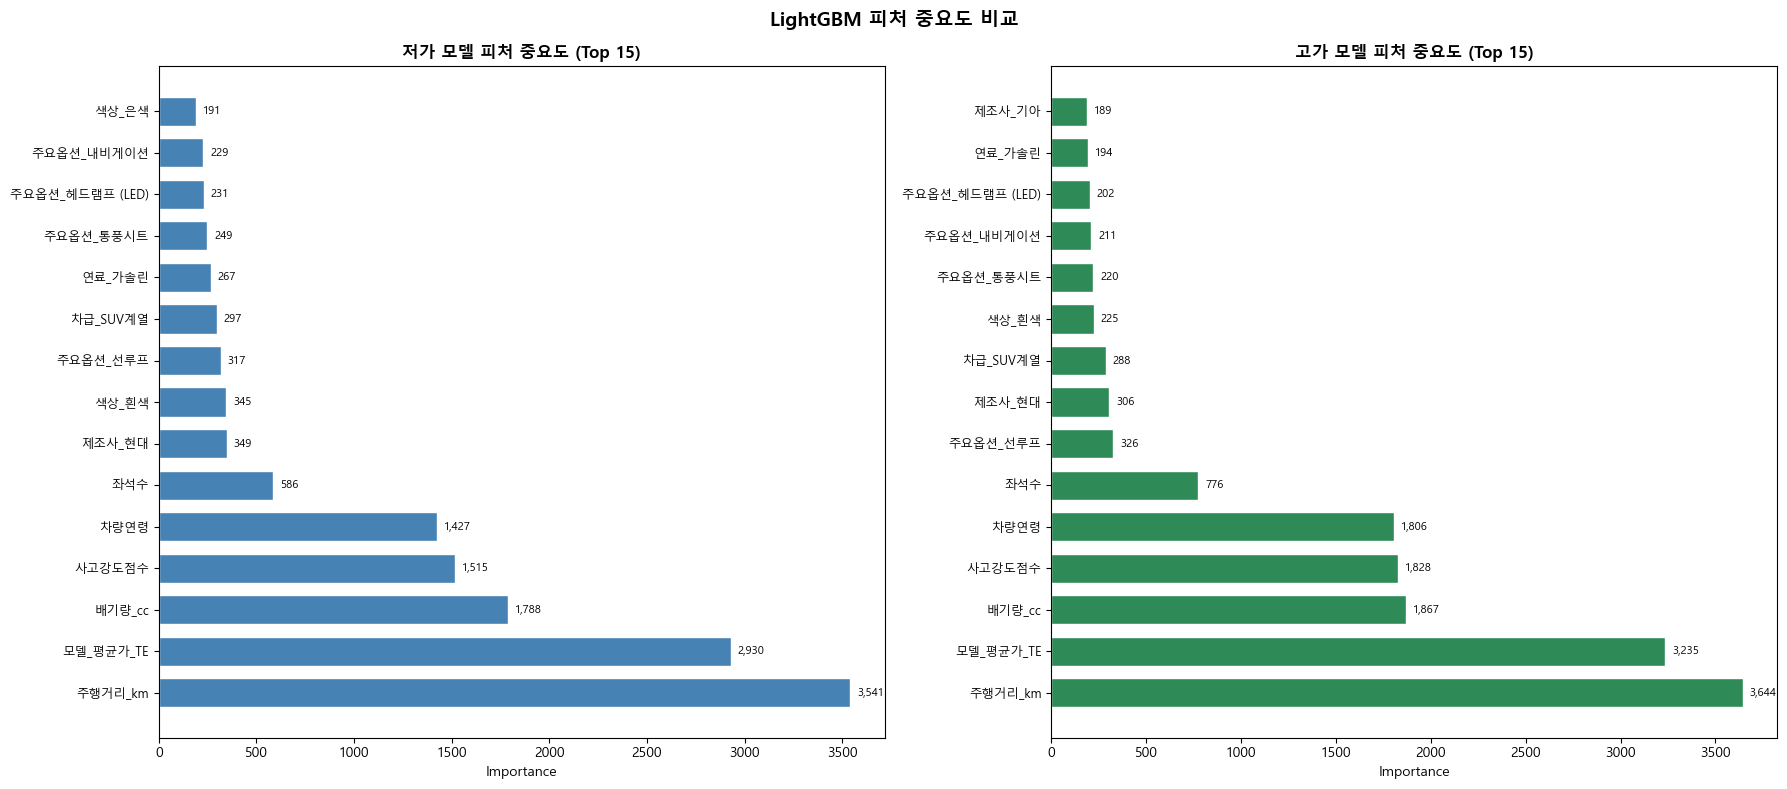

✅ 피처 중요도 저장 완료


In [10]:
# 피처 중요도 수치 직접 출력
fi_low_top15  = fi_low.head(15).round(0).astype(int)
fi_high_top15 = fi_high.head(15).round(0).astype(int)

print("【 저가 모델 (q50) - Top 15 】")
for i, (feat, val) in enumerate(fi_low_top15.items(), 1):
    bar = '█' * (val // (fi_low_top15.max() // 20))
    print(f"  {i:2d}. {feat:<25} {val:>6,}  {bar}")

print("\n【 고가 모델 (q50) - Top 15 】")
for i, (feat, val) in enumerate(fi_high_top15.items(), 1):
    bar = '█' * (val // (fi_high_top15.max() // 20))
    print(f"  {i:2d}. {feat:<25} {val:>6,}  {bar}")

# 두 모델 중요도 차이 비교
fi_diff = pd.DataFrame({
    '저가_모델': fi_low,
    '고가_모델': fi_high
})
fi_diff['차이(고가-저가)'] = fi_diff['고가_모델'] - fi_diff['저가_모델']
fi_diff = fi_diff.sort_values('고가_모델', ascending=False).head(15)

print("\n【 저가 vs 고가 모델 피처 중요도 비교 (Top 15) 】")
print(f"{'피처':<25} {'저가모델':>8} {'고가모델':>8} {'차이':>8}")
print("─" * 55)
for feat, row in fi_diff.iterrows():
    diff_str = f"+{row['차이(고가-저가)']:.0f}" if row['차이(고가-저가)'] >= 0 \
               else f"{row['차이(고가-저가)']:.0f}"
    print(f"  {feat:<23} {row['저가_모델']:>8,.0f} {row['고가_모델']:>8,.0f} {diff_str:>8}")

# 시각화 재시도 (단일 figure로 통합)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_n = 15
fi_low_plot  = fi_low.head(top_n)
fi_high_plot = fi_high.head(top_n)

for ax, fi_data, title, color in zip(
    axes,
    [fi_low_plot, fi_high_plot],
    ['저가 모델 피처 중요도 (Top 15)', '고가 모델 피처 중요도 (Top 15)'],
    ['steelblue', 'seagreen']
):
    y_pos = range(top_n)
    ax.barh(y_pos, fi_data.values[::-1][::-1],
            color=color, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(fi_data.index, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    for j, val in enumerate(fi_data.values):
        ax.text(val + fi_data.max()*0.01, j,
                f'{val:,.0f}', va='center', fontsize=8)

plt.suptitle('LightGBM 피처 중요도 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\eda\07_feature_importance.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ 피처 중요도 저장 완료")


## 피처 중요도 최종 해석

### 공통 핵심 피처 (저가·고가 동일)

```
순위   피처             저가    고가     의미
────────────────────────────────────────────────
 1    주행거리_km       3,541   3,644   ← 압도적 1위, 두 모델 모두
 2    모델_평균가_TE    2,930   3,235   ← 차종 자체의 시장가 반영
 3    배기량_cc        1,788   1,867   ← 차급·성능 proxy
 4    사고강도점수      1,515   1,828   ← 고가일수록 사고 영향 ↑
 5    차량연령         1,427   1,806   ← 고가일수록 연식 영향 ↑
```

**상위 5개 피처가 전체 중요도의 약 75% 이상 설명**

---

### 저가 vs 고가 모델 차이 분석

#### ✅ 고가 모델에서 중요도가 더 높은 피처
| 피처 | 차이 | 해석 |
|---|:---:|---|
| 차량연령 | **+379** | 고가 차량일수록 연식에 따른 감가가 민감 |
| 사고강도점수 | **+313** | 고가 차량 사고이력이 가격에 더 큰 타격 |
| 모델_평균가_TE | **+305** | 고가 구간에서 모델 브랜드 영향력 강화 |
| 좌석수 | **+190** | 고가 대형·승합 차량에서 좌석수가 변별력 |

#### ✅ 저가 모델에서 중요도가 더 높은 피처
| 피처 | 차이 | 해석 |
|---|:---:|---|
| 색상_흰색 | **-120** | 저가 차량에서 흰색 선호도가 가격에 영향 |
| 연료_가솔린 | **-73** | 저가 구간 = 가솔린 소형차 밀집 구간 |
| 제조사_현대 | **-43** | 저가 구간에서 현대 브랜드 변별력 존재 |

---

### 핵심 인사이트 요약

```
① 주행거리가 가장 중요한 가격 결정 요소
   저가·고가 모두 1위 → 보편적이고 강력한 신호

② 고가 차량은 "연식·사고" 에 더 민감
   차량연령 +379 / 사고강도 +313
   → 비싼 차일수록 조금만 오래되거나 사고나도 가격 급락

③ 저가 차량은 "색상·연료·제조사" 가 상대적으로 중요
   → 저가 구간은 옵션·외관 조건이 가격 결정에 영향

④ 모델_평균가_TE는 두 모델 모두 2위
   → Target Encoding이 차종 시장가를 잘 반영
```

---

### 🏁 전체 프로젝트 완료 요약

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 단계       내용                       결과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. EDA     11,617개 데이터 분석        이상치·분포 확인
 2. 전처리   로그변환·분산필터·분할       32개 피처 확정
 3. 베이스라인 6개 모델 비교             LightGBM 최우수
 4. Quantile q10/q90 → q05/q95 실험   Coverage vs Width 확인
 5. Optuna  LightGBM 50 trial 튜닝    MAE 279.9만원
 6. Hybrid  가격대별 분위수 분리         Coverage 80.4% 달성
 7. 저장     pkl 3개 저장               예측 함수 구현 완료
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 최종 성능   Coverage 80.4%
            Width    956만원
            MAE      280.4만원
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```
